##### top

# This ntb contains figures for the FMP paper

Figure 1 is a methods figure and is not part of this notebook.

* [Figure 2](#Figure-2)
    * [Stats Figure 2](#Stats-Figure-2)
* [Figure 3](#Figure-3)
* [Figure 4](#Figure-4)
* [Figure 5](#Figure-5)
* [Figure 6](#Figure-6)
* [Figure 7](#Figure-7)
    * [Compute d'](#Compute-d')

In [1]:
import os, sys
from os.path import join as opj
import pickle
import arviz as az
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pingouin as pg

# Importing module for functions
functions_modul =  "../Code/functions"
sys.path.insert(0, functions_modul)

# import all processing and plotting functions
from plot_functions import label_correlation, label_column_height, change_width, sharey_ax, star_gazing, sharey_name, \
get_flattened_palette, map_rev_palette, plot_FMP_results_slopes, plot_significance_pairs, plot_cue_stimulus_slopes, plot_cue_stim_by_task
from composite_measures_functions import calculate_d_prime

# define orders
hue_order = ['Matching', 'Unfilled Delay', 'Filled Delay - emotions']
hue_order_math = ['Matching', 'Unfilled Delay', 'Filled Delay - math', 'Filled Delay - emotions']
hue_order_veg = ['Matching', 'Unfilled Delay', 'Filled Delay - vis', 'Filled Delay - emotions']

path_data = '../Data'
path_datasets = '../Data/datasets'
path_figures = '../Figures'

dic_task2abbreviations = {
    '2': 'PL-2',
    '3': 'PL-3',
    'interference': 'FD-e',
    'face matching': 'M',
    'unfilled delay': 'UD',
    'delay': 'UD',
    'math': 'FD-m',
    'Matching': 'M',
    'Unfilled Delay': 'UD',
    'Filled Delay - emotions': 'FD-e',
    'Filled Delay - math': 'FD-m',
    'Filled Delay - vis': 'FD-v',
    'target_0': 'Unmorphed image',#'Original image'
}


# load all dataframes
df_dic = {}

for file in ['FMP_dataset_1.csv', 'FMP_dataset_1b.csv', 'FMP_dataset_2.csv', 'FMP_dataset_3.csv', 
             'FMP_dataset_4.csv', 'FMP_dataset_5.csv', 'FMP_dataset_6.csv', 'FMP_concat_datasets_123.csv']:
    f = file.replace('FMP_', '').replace('.csv', '')
    df_dic[f] = pd.read_csv(os.path.join(path_datasets, file))
    
    df_dic[f]["Experiment"] = f
        

    # clean
    df_dic[f].reset_index(drop=True, inplace=True)
    
    if 'Unnamed: 0' in df_dic[f].columns:
        df_dic[f].drop('Unnamed: 0', inplace=True, axis=1)
        


/var/folders/bx/tb4883l53hdd3zp2y0nyy_4m0000gp/T/ipykernel_83736/3328029218.py:52: DtypeWarning: Columns (10,11) have mixed types. Specify dtype option on import or set low_memory=False.
  df_dic[f] = pd.read_csv(os.path.join(path_datasets, file))


## Figure 2
[top](#top)

In [2]:
# Load the dictionary from the pickle file
with open(opj(path_data,'model_inference_data', 'FMP_Figure_2_inference_data_dict.pkl'), 'rb') as f:
    FMP_inference_data_dict = pickle.load(f)

../Code/functions/plot_functions.py:190: UserWarning: The palette list has more values (9) than needed (3), which may not be intended.
  bars = sns.barplot(x='difficulty', y='correct_flt', data=data,
../Code/functions/plot_functions.py:195: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:k'` for the same effect.

  stripplot = sns.stripplot(x='difficulty', y='correct_flt',


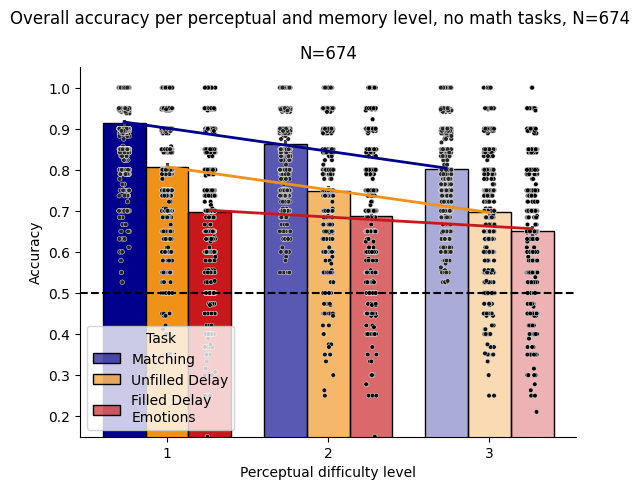

In [3]:
# create a special data
data = df_dic['concat_datasets_123'].copy()

fig, ax = plt.subplots(1,1)

plot_FMP_results_slopes(data, ax, get_flattened_palette(hue_order))
            
plt.suptitle(f"Overall accuracy per perceptual and memory level, no math tasks, N={data.userID.unique().size}", 
             y=1.0)


# plt.savefig(os.path.join('/Users/jan/Downloads', 'fig2_FMP.pdf'), dpi=150, bbox_inches="tight")
plt.show()

{'name': 'Arial'}
Overall accuracy per perceptual and memory level, no math tasks, N=674


../Code/functions/plot_functions.py:190: UserWarning: The palette list has more values (9) than needed (3), which may not be intended.
  bars = sns.barplot(x='difficulty', y='correct_flt', data=data,
../Code/functions/plot_functions.py:195: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:k'` for the same effect.

  stripplot = sns.stripplot(x='difficulty', y='correct_flt',
../Code/functions/plot_functions.py:190: UserWarning: The palette list has more values (9) than needed (3), which may not be intended.
  bars = sns.barplot(x='difficulty', y='correct_flt', data=data,
../Code/functions/plot_functions.py:195: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:k'` for the same effect.

  stripplot = sns.stripplot(x='difficulty', y='correct_flt',
../Code/functions/plot_functions.py:190: UserWarning: The palette list has more values (9) than need

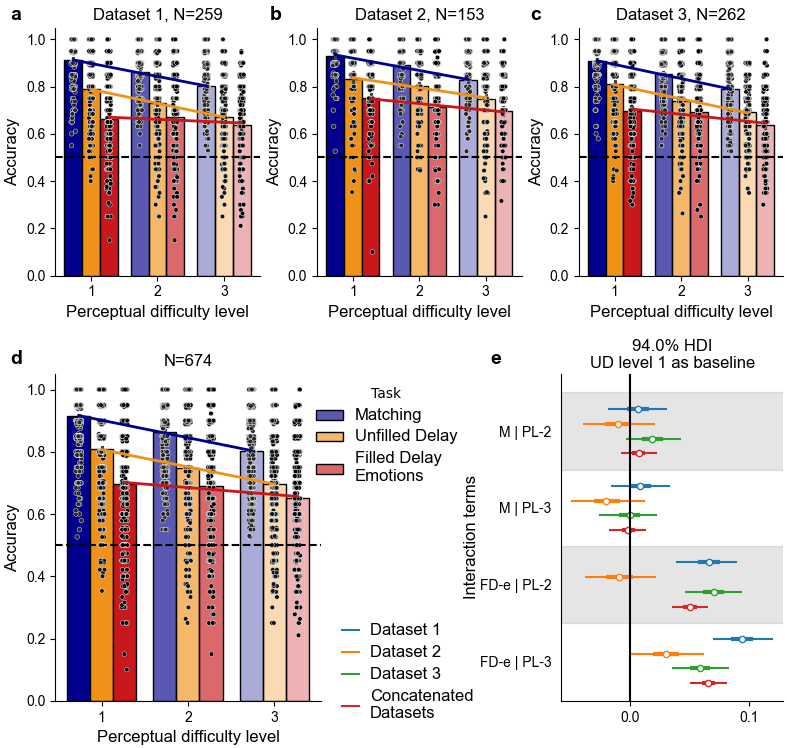

In [4]:
#######################
# define canvas

from cand import Canvas, Vector, Point
import matplotlib.ticker as ticker


##### deal with data and colours
# to make all stripplots look the same and avoid the random jitter
# https://stackoverflow.com/questions/61944815/how-to-set-seed-for-jitter-in-seaborn-stripplot
np.random.seed(123)

#######


# reset params just in case
plt.rcdefaults()

font_size=14
legend_size=10


# CanD
a = 20
b = 19
# rot = 15
c = Canvas(a, b, "cm")

# set font
# c.set_font("Helvetica", size=10)
c.set_font("Arial", size=12, ticksize=legend_size)

# letters
# c.add_text("A", Point(.05, 0.98), weight="bold")
# c.add_text("A)", Point(.02, 0.98), weight="bold", size=font_size)
# c.add_text("B)", Point(.02, 0.5), weight="bold", size=font_size)

c.add_text("a", Point(.02, 0.98), weight="bold", size=font_size)
c.add_text("b", Point(.35, 0.98), weight="bold", size=font_size)
c.add_text("c", Point(.68, 0.98), weight="bold", size=font_size)
c.add_text("d", Point(.02, 0.52), weight="bold", size=font_size)
c.add_text("e", Point(.63, 0.52), weight="bold", size=font_size)
           
# titles
titles = [f"Overall accuracy per perceptual and memory level, no math tasks, N={df_dic['concat_datasets_123'].userID.unique().size}"]
# c.add_text(titles[0], Point(.5, 0.96), size=font_size)

for title in titles:
    print(title)

# ### GRID
# # top row, panel A
top_offset = .7
bottom_offset = 1.2
left_offset = 1.4
hsb = 1 #half_space_between - horizontal
vsb = 1.45 #half_space_between - vertical
middle_h = 9.5
middle_v = 13 # between the bottom two
vsb_bottom = 1.25 # space between the bottom two

# add a 1x3 grid
c.add_grid(["FMP", "FMP_S", "FMP_order"], 1, Point(left_offset, middle_h+2.5, "cm"), Point(a-.1, b-top_offset, "cm"), spacing=Vector(vsb, hsb, "cm"), unitname="tasks")
# add a 1x1 grid
c.add_grid(["combined"], 1, Point(left_offset, bottom_offset, "cm"), Point(middle_v-3.6-vsb_bottom, middle_h, "cm"), spacing=Vector(vsb, hsb, "cm"), unitname="grid")
c.add_grid(["interactions"], 1, Point(middle_v+vsb_bottom, bottom_offset, "cm"), Point(a-.1, middle_h, "cm"), spacing=Vector(vsb, hsb, "cm"))


######### panel A
plot_FMP_results_slopes(df_dic['dataset_1'], c.ax("FMP"), get_flattened_palette(hue_order), plot_legend=False, title='Dataset 1, ')
plot_FMP_results_slopes(df_dic['dataset_2'], c.ax("FMP_S"), get_flattened_palette(hue_order), plot_legend=False, title='Dataset 2, ')
plot_FMP_results_slopes(df_dic['dataset_3'], c.ax("FMP_order"), get_flattened_palette(hue_order), plot_legend=False, title='Dataset 3, ')

######### bottom row
plot_FMP_results_slopes(df_dic['concat_datasets_123'], c.ax("combined"), get_flattened_palette(hue_order), 
                        legend_kwargs={"loc":"upper right", "bbox_to_anchor":(1.56, 1), "frameon":False})

# add y-axis to start at 0
for ax_name in ["FMP", "FMP_S", "FMP_order", "combined"]:
    c.ax(ax_name).set_ylim(bottom=0)
    
### plot interactions

az.plot_forest(
    (list(FMP_inference_data_dict['dataset_1'].values())+\
    list(FMP_inference_data_dict['dataset_2'].values())+\
    list(FMP_inference_data_dict['dataset_3'].values())+\
    list(FMP_inference_data_dict['concat_datasets_123'].values())
    )[::2],
    model_names=[f'{f}' for f in FMP_inference_data_dict.keys()],
    var_names=["task:difficulty"],
    combined=True,
    ax=c.ax("interactions")
)

# # manually adjust the legend, there is some weird bug
legend = c.ax("interactions").get_legend()
labels = [] if legend is None else [str(x._text).replace('concat_datasets_123', 'concatenated\ndatasets').replace('_', ' ').title() for x in legend.texts]
handles = [] if legend is None else legend.legendHandles #legend.legend_handles
# # and switch the order of the vars in the legend as it it reversed for some reason
# # legend on the side
c.ax("interactions").legend(handles[::-1], labels[::-1], loc="lower left", bbox_to_anchor=(-1.04, -.1), handlelength=1.2, frameon=False)

# update y ticks
c.ax("interactions").set_yticklabels([
    ' | '.join(dic_task2abbreviations.get(word.strip(), word.strip()) for word in x.get_text().split('[')[1].strip(']').split(','))
    if '[' in x.get_text() else x.get_text()
    for x in c.ax("interactions").get_yticklabels()
])

c.ax("interactions").set_ylabel('Interaction terms', labelpad=0.5)
c.ax("interactions").axvline(0, c='k')
# c.ax("interactions").set_xlabel('')

# add title
c.ax("interactions").set_title(f'{c.ax("interactions").get_title()}\nUD level 1 as baseline')

for ax in c.axes.values():
    sns.despine(ax=ax)
#     ax.axvline(0, c='k')
        

    
# c.debug_grid(Vector(0.5,0.5,"cm"))
c.show()
#
c.save(os.path.join(path_figures, "Fig2", 'Figure_2.png'), dpi=300)#, bbox_inches="tight")
c.save(os.path.join(path_figures, "Fig2", 'Figure_2.pdf'), dpi=300)#, bbox_inches="tight")


### Stats Figure 2
[top](#top)

In [5]:
aov = pg.anova(data=df_dic['dataset_1'].groupby(['userID', 'task', 'difficulty']).mean(numeric_only=True).reset_index(), 
               dv='correct_flt', between=['task', 'difficulty'], detailed=True)
aov['star_gazing'] = aov['p-unc'].apply(star_gazing)

aov

,Source,SS,DF,MS,F,p-unc,np2,star_gazing
0,task,15.961413,2.0,7.980706,434.649105,5.241237e-161,0.272910,***
1,difficulty,2.738859,2.0,1.369429,74.582526,4.069829e-32,0.060509,***
2,task * difficulty,0.728853,4.0,0.182213,9.923789,5.826041e-08,0.016851,***
3,Residual,42.524684,2316.0,0.018361,NaN,NaN,NaN,


In [6]:
aov = pg.anova(data=df_dic['dataset_2'].groupby(['userID', 'task', 'difficulty']).mean(numeric_only=True).reset_index(), 
               dv='correct_flt', between=['task', 'difficulty'], detailed=True)
aov['star_gazing'] = aov['p-unc'].apply(star_gazing)

aov

,Source,SS,DF,MS,F,p-unc,np2,star_gazing
0,task,5.956256,2,2.978128,174.221952,3.946702e-68,0.203003,***
1,difficulty,1.506070,2,0.753035,44.052927,2.876831e-19,0.060508,***
2,task * difficulty,0.136906,4,0.034227,2.002268,9.188816e-02,0.005821,
3,Residual,23.384417,1368,0.017094,NaN,NaN,NaN,


In [7]:
aov = pg.anova(data=df_dic['dataset_3'].groupby(['userID', 'task', 'difficulty']).mean(numeric_only=True).reset_index(), 
               dv='correct_flt', between=['task', 'difficulty'], detailed=True)
aov['star_gazing'] = aov['p-unc'].apply(star_gazing)

aov

,Source,SS,DF,MS,F,p-unc,np2,star_gazing
0,task,11.956352,2.0,5.978176,403.291598,3.653178e-151,0.256826,***
1,difficulty,3.852945,2.0,1.926472,129.961076,3.061592e-54,0.100204,***
2,task * difficulty,0.447820,4.0,0.111955,7.552553,4.827866e-06,0.012778,***
3,Residual,34.597949,2334.0,0.014823,NaN,NaN,NaN,


In [8]:
aov = pg.anova(data=df_dic['concat_datasets_123'].groupby(['userID', 'task', 'difficulty']).mean(numeric_only=True).reset_index(), 
               dv='correct_flt', between=['task', 'difficulty'], detailed=True)
aov['star_gazing'] = aov['p-unc'].apply(star_gazing)

aov

,Source,SS,DF,MS,F,p-unc,np2,star_gazing
0,task,33.486907,2.0,16.743453,975.833395,0.000000e+00,0.244335,***
1,difficulty,8.025744,2.0,4.012872,233.876164,1.486772e-98,0.071920,***
2,task * difficulty,1.059064,4.0,0.264766,15.430952,1.458493e-12,0.010122,***
3,Residual,103.566332,6036.0,0.017158,NaN,NaN,NaN,


---
Repeated measures ANOVA

In [9]:
aov = pg.rm_anova(data=df_dic['dataset_1'],
                  dv='correct_flt', within=['task', 'difficulty'],
                  subject='userID')

aov['star_gazing'] = aov['p-unc'].apply(star_gazing)

aov

/Users/jan/Documents/PhD/papers/FMP/FMP_github/venv/lib/python3.8/site-packages/pingouin/distribution.py:515: UserWarning: Epsilon values might be innaccurate in two-way repeated measures design where each  factor has more than 2 levels. Please  double-check your results.
  warnings.warn(


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps,star_gazing
0,task,16.083329,2,512,8.041665,398.614888,4.140437e-105,2.839192e-97,0.276004,0.923133,***
1,difficulty,2.744820,2,512,1.372410,159.768361,1.211890e-54,1.122459e-53,0.061086,0.981291,***
2,task * difficulty,0.743008,4,1024,0.185752,21.455269,5.158246e-17,1.605759e-13,0.017307,0.761461,***


In [10]:
aov = pg.rm_anova(data=df_dic['dataset_2'],
                  dv='correct_flt', within=['task', 'difficulty'],
                  subject='userID')

aov['star_gazing'] = aov['p-unc'].apply(star_gazing)

aov

/Users/jan/Documents/PhD/papers/FMP/FMP_github/venv/lib/python3.8/site-packages/pingouin/distribution.py:515: UserWarning: Epsilon values might be innaccurate in two-way repeated measures design where each  factor has more than 2 levels. Please  double-check your results.
  warnings.warn(


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps,star_gazing
0,task,5.956256,2,304,2.978128,155.646437,2.859816e-47,7.387689e-46,0.203003,0.968198,***
1,difficulty,1.506070,2,304,0.753035,94.714100,1.063511e-32,2.938077e-32,0.060508,0.985266,***
2,task * difficulty,0.136906,4,608,0.034227,4.958732,6.125480e-04,2.370727e-03,0.005821,0.729378,***


In [11]:
aov = pg.rm_anova(data=df_dic['dataset_3'],
                  dv='correct_flt', within=['task', 'difficulty'],
                  subject='userID')

aov['star_gazing'] = aov['p-unc'].apply(star_gazing)

aov

/Users/jan/Documents/PhD/papers/FMP/FMP_github/venv/lib/python3.8/site-packages/pingouin/distribution.py:515: UserWarning: Epsilon values might be innaccurate in two-way repeated measures design where each  factor has more than 2 levels. Please  double-check your results.
  warnings.warn(


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps,star_gazing
0,task,11.873927,2,512,5.936964,358.240484,4.952120e-98,1.166163e-94,0.258453,0.964461,***
1,difficulty,3.855001,2,512,1.927501,224.492376,9.946881e-71,2.202754e-70,0.101652,0.994898,***
2,task * difficulty,0.468995,4,1024,0.117249,14.021673,3.832418e-11,9.509245e-10,0.013579,0.843929,***


In [12]:
aov = pg.rm_anova(data=df_dic['dataset_4'],
                  dv='correct_flt', within=['task', 'difficulty'],
                  subject='userID')

aov['star_gazing'] = aov['p-unc'].apply(star_gazing)

aov

/Users/jan/Documents/PhD/papers/FMP/FMP_github/venv/lib/python3.8/site-packages/pingouin/distribution.py:515: UserWarning: Epsilon values might be innaccurate in two-way repeated measures design where each  factor has more than 2 levels. Please  double-check your results.
  warnings.warn(


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps,star_gazing
0,task,6.709305,3,447,2.236435,109.585743,3.409679e-53,1.883017e-51,0.165825,0.965399,***
1,difficulty,2.127939,2,298,1.063970,120.452922,4.600472e-39,6.311970e-39,0.059309,0.996212,***
2,task * difficulty,0.078373,6,894,0.013062,1.478286,1.824426e-01,1.988442e-01,0.002317,0.776356,


In [13]:
aov = pg.rm_anova(data=df_dic['dataset_5'],
                  dv='correct_flt', within=['task', 'difficulty'],
                  subject='userID')

aov['star_gazing'] = aov['p-unc'].apply(star_gazing)

aov

/Users/jan/Documents/PhD/papers/FMP/FMP_github/venv/lib/python3.8/site-packages/pingouin/distribution.py:515: UserWarning: Epsilon values might be innaccurate in two-way repeated measures design where each  factor has more than 2 levels. Please  double-check your results.
  warnings.warn(


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps,star_gazing
0,task,2.761487,3,246,0.920496,52.307206,3.463916e-26,1.124051e-23,0.121868,0.893785,***
1,difficulty,1.169473,2,164,0.584737,57.997009,8.933012e-20,1.817735e-19,0.055510,0.982123,***
2,task * difficulty,0.114747,6,492,0.019124,2.142562,4.732617e-02,6.387483e-02,0.005734,0.783734,*


In [14]:
aov = pg.rm_anova(data=df_dic['concat_datasets_123'],
                  dv='correct_flt', within=['task', 'difficulty'],
                  subject='userID')

aov['star_gazing'] = aov['p-unc'].apply(star_gazing)

aov

/Users/jan/Documents/PhD/papers/FMP/FMP_github/venv/lib/python3.8/site-packages/pingouin/distribution.py:515: UserWarning: Epsilon values might be innaccurate in two-way repeated measures design where each  factor has more than 2 levels. Please  double-check your results.
  warnings.warn(


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps,star_gazing
0,task,33.542748,2,1332,16.771374,893.517002,7.987684e-247,1.987379e-235,0.246254,0.953155,***
1,difficulty,8.031337,2,1332,4.015669,473.952353,3.526103e-156,2.087169e-154,0.072550,0.988398,***
2,task * difficulty,1.084278,4,2664,0.271070,32.990067,6.879639e-27,6.145754e-22,0.010451,0.796389,***


In [15]:
aov = pg.rm_anova(data=df_dic['concat_datasets_123'].groupby(['userID', 'task', 'difficulty']).mean(numeric_only=True).reset_index(),
                  dv='correct_flt', within=['task', 'difficulty'],
                  subject='userID')

aov['star_gazing'] = aov['p-unc'].apply(star_gazing)

aov

/Users/jan/Documents/PhD/papers/FMP/FMP_github/venv/lib/python3.8/site-packages/pingouin/distribution.py:515: UserWarning: Epsilon values might be innaccurate in two-way repeated measures design where each  factor has more than 2 levels. Please  double-check your results.
  warnings.warn(


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps,star_gazing
0,task,33.542748,2,1332,16.771374,893.517002,7.987684e-247,1.987379e-235,0.246254,0.953155,***
1,difficulty,8.031337,2,1332,4.015669,473.952353,3.526103e-156,2.087169e-154,0.072550,0.988398,***
2,task * difficulty,1.084278,4,2664,0.271070,32.990067,6.879639e-27,6.145754e-22,0.010451,0.796389,***


---

## Figure 3
[top](#top)

Cue stimulus effect

../Code/functions/plot_functions.py:478: UserWarning: The palette list has more values (9) than needed (3), which may not be intended.
  bars = sns.barplot(x='difficulty', y='correct_flt', data=data,
../Code/functions/plot_functions.py:484: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:k'` for the same effect.

  stripplot = sns.stripplot(x='difficulty', y='correct_flt',
../Code/functions/plot_functions.py:478: UserWarning: The palette list has more values (9) than needed (3), which may not be intended.
  bars = sns.barplot(x='difficulty', y='correct_flt', data=data,
../Code/functions/plot_functions.py:484: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:k'` for the same effect.

  stripplot = sns.stripplot(x='difficulty', y='correct_flt',


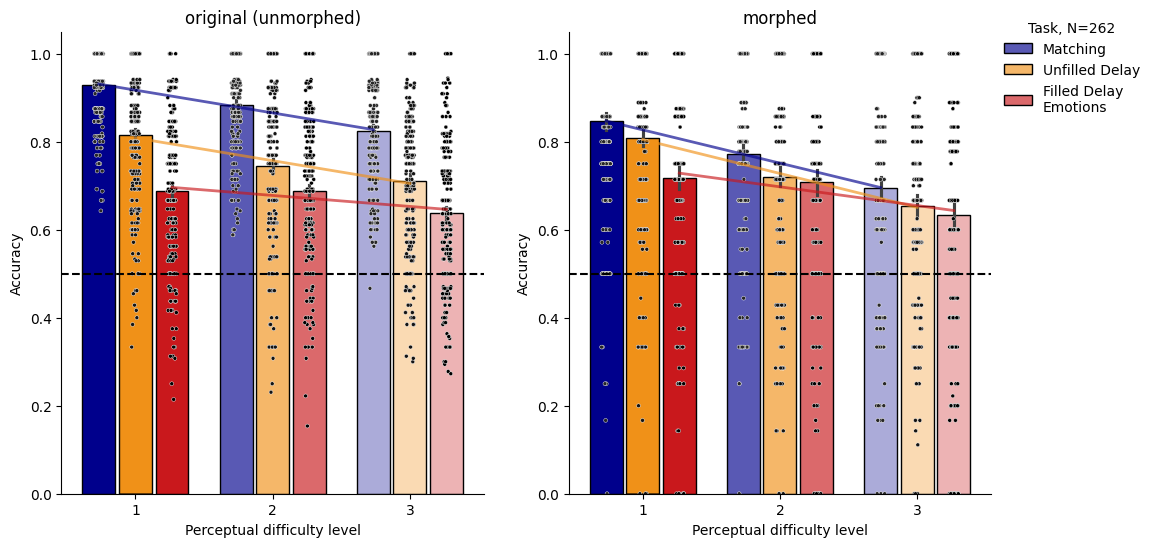

In [16]:
fig, axs = plt.subplots(1,2, figsize=(12,6))

plot_cue_stimulus_slopes(df_dic['dataset_3'], axs.flatten(), hue_order)


---

In [17]:
# define colours to recolour bars
doubled_palette = [
    (0, 0, 0.55, 1),
    (0, 0, 0.55, 0.65),
    (0, 0, 0.55, 0.33),
    (0, 0, 0.55, 1),
    (0, 0, 0.55, 0.65),
    (0, 0, 0.55, 0.33),
#    
    (0.94, 0.57, 0.095, 1),
    (0.94, 0.57, 0.095, 0.65),
    (0.94, 0.57, 0.095, 0.33),
    (0.94, 0.57, 0.095, 1),
    (0.94, 0.57, 0.095, 0.65),
    (0.94, 0.57, 0.095, 0.33),
#    
    (0.79, 0.093, 0.11, 1),
    (0.79, 0.093, 0.11, 0.65),
    (0.79, 0.093, 0.11, 0.33),
    (0.79, 0.093, 0.11, 1),
    (0.79, 0.093, 0.11, 0.65),
    (0.79, 0.093, 0.11, 0.33),
]

#### Load the inference data

In [18]:
# Load the dictionary from the pickle file
with open(opj(path_data, 'model_inference_data', 'FMP_cue_stimulus_inference_data_dict.pkl'), 'rb') as f:
    FMP_cue_stim_interaction_inference_data_dict = pickle.load(f)
    
    
# Load the dictionary from the pickle file
with open(opj(path_data, 'model_inference_data', 'FMP_Figure_4_cue_stim_inference_data_dict.pkl'), 'rb') as f:
    FMP_cue_stim_inference_data_dict = pickle.load(f)
    
    
location_order = ['dataset_3_target_0', 'dataset_3_other']
location_rename_dic = {
    'dataset_3_target_0': 'Unmorphed',
    'dataset_3_other': 'Morphed',
}

# check that the N is the same
assert FMP_cue_stim_inference_data_dict['dataset_3_other']['correct_flt ~ task * difficulty + (1|userID)']['posterior']['userID__factor_dim'].size == FMP_cue_stim_inference_data_dict['dataset_3_target_0']['correct_flt ~ task * difficulty + (1|userID)']['posterior']['userID__factor_dim'].size
N_cue_stim = FMP_cue_stim_inference_data_dict['dataset_3_other']['correct_flt ~ task * difficulty + (1|userID)']['posterior']['userID__factor_dim'].size


In [19]:
df_select = df_dic['dataset_3'].copy()
# name_loc_dic = {'all':'all','other':'morphed','target_0':'unmorphed'}
name_loc_dic={'all':'all','other':'morphed','target_0':'original'}

# fix naming
df_select['target_loc_simple'] = df_select['target_loc_simple'].map(name_loc_dic)

{'name': 'Arial'}
Experiment design
Posterior distributions in Dataset 3 for correct_flt ~ task * difficulty * target_loc_simple + (1|userID)


../Code/functions/plot_functions.py:585: UserWarning: The palette list has more values (9) than needed (2), which may not be intended.
  bars = sns.barplot(x='difficulty', y='correct_flt', data=df_select[df_select['task'] == tsk],
../Code/functions/plot_functions.py:591: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:k'` for the same effect.

  stripplot = sns.stripplot(x='difficulty', y='correct_flt',
../Code/functions/plot_functions.py:585: UserWarning: The palette list has more values (9) than needed (2), which may not be intended.
  bars = sns.barplot(x='difficulty', y='correct_flt', data=df_select[df_select['task'] == tsk],
../Code/functions/plot_functions.py:591: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:k'` for the same effect.

  stripplot = sns.stripplot(x='difficulty', y='correct_flt',
../Code/functions/plot_functions.py:58

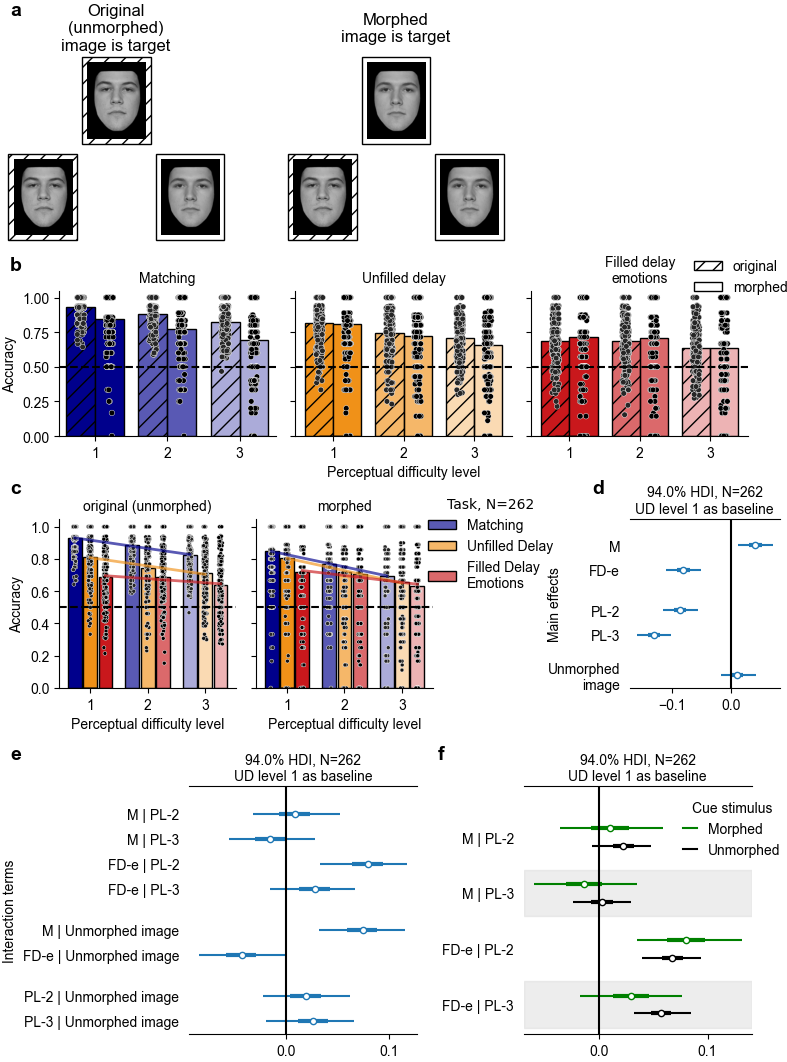

In [20]:
from cand import Canvas, Vector, Point

# to make all stripplots look the same and avoid the random jitter
# https://stackoverflow.com/questions/61944815/how-to-set-seed-for-jitter-in-seaborn-stripplot
np.random.seed(123)


# CanD
a = 20
b = 27#2
c = Canvas(a, b, "cm")

# set font
c.set_font("Arial", size=10)



# letters
# c.add_text("A)", Point(.02, 0.97), size=font_size)
c.add_text("a", Point(.02, 0.99), weight="bold", size=font_size)
# c.add_text("d", Point(.02, 0.52), weight="bold", size=font_size)
c.add_text("b", Point(.02, 0.75), weight="bold", size=font_size)
c.add_text("c", Point(.02, 0.54), weight="bold", size=font_size)
c.add_text("d", Point(.76, 0.54), weight="bold", size=font_size)
c.add_text("e", Point(.02, 0.29), weight="bold", size=font_size)
c.add_text("f", Point(.56, 0.29), weight="bold", size=font_size)
           
# titles
formula = 'correct_flt ~ task * difficulty * target_loc_simple + (1|userID)'
titles = ["Experiment design", f"Posterior distributions in Dataset 3 for {formula}"]
# c.add_text(titles[0], Point(.55, 0.97), size=font_size)
for title in titles:
    print(title)


##################
### Plot methods
img_width=4/2.55
img_height=5/2.56
x_im = 0.061 #0.052
y_im = 0.062 #0.054
colour_unmorphed = 'k'#'lawngreen'#'darkgreen'#'mediumpurple'
colour_morphed = 'k'#'fuchsia'#'darkkhaki'#'y'

left_offset = 0.3
top_offset = 2.1
h_gap_between_squares = 0.5#0.3
v_gap_between_triangles = 2.4+3*img_width
v_gap_between_faces = .3#0

# grid
c.add_grid(["leftimg"], 1, Point(left_offset, b-2*img_height-top_offset, "cm"),  Point(img_width+left_offset,  b-img_height-top_offset, "cm"), spacing=Vector(.5, 2.5, "cm"))
# c.add_grid(["middleimg"], 1, Point(img_width, img_height, "leftimg"),  Point(2*img_width,  2*img_height, "leftimg"), spacing=Vector(.5, .5, "cm"))
# c.add_grid(["middleimg"], 1, Point(0, 0, "leftimg"),  Point(img_width/10,  img_height/10, "leftimg"), spacing=Vector(.5, .5, "cm"))
c.add_grid(["middleimg"], 1, Point(left_offset+img_width+v_gap_between_faces, b-img_height-top_offset+h_gap_between_squares, "cm"),  Point(left_offset+2*img_width+v_gap_between_faces,  b-top_offset+h_gap_between_squares, "cm"), spacing=Vector(.5, 2.5, "cm"))
c.add_grid(["rightimg"], 1, Point(left_offset+2*img_width+2*v_gap_between_faces, b-2*img_height-top_offset, "cm"),  Point(left_offset+3*img_width+2*v_gap_between_faces, b-img_height-top_offset, "cm"), spacing=Vector(.5, 2.5, "cm"))

# frame
c.add_rect(Point(-x_im, -y_im, "leftimg"), Point(x_im, y_im, "leftimg"), fill=None, linewidth=1, color=colour_unmorphed, hatch='//', zorder=0)
c.add_rect(Point(-x_im, -y_im, "middleimg"), Point(x_im, y_im, "middleimg"), fill=None, linewidth=1, color=colour_unmorphed, hatch='//', zorder=0)
c.add_rect(Point(-x_im, -y_im, "rightimg"), Point(x_im, y_im, "rightimg"), fill=None, linewidth=1, color=colour_morphed)


# images that can be published
c.axes["leftimg"].imshow(plt.imread('/Users/jan/Documents/PhD/methodology_FMFP/london_faces/sharp_London-M-069-03_London-M-068-03_0p.png'))
# c.axes["leftimg"].axis("off")
c.axes["middleimg"].imshow(plt.imread('/Users/jan/Documents/PhD/methodology_FMFP/london_faces/sharp_London-M-069-03_London-M-068-03_0p.png'))
c.axes["rightimg"].imshow(plt.imread('/Users/jan/Documents/PhD/methodology_FMFP/london_faces/sharp_London-M-069-03_London-M-068-03_36p.png'))


# remove the numbers
for f in ["leftimg", "middleimg", "rightimg"]:
    c.axes[f].axis("off")

# add text
c.add_text("Original\n(unmorphed)\nimage is target", Point(200,-240, "middleimg"), color='k', size=12)


##----
# grid
c.add_grid(["leftimg_2"], 1, Point(left_offset+v_gap_between_triangles, b-2*img_height-top_offset, "cm"),  Point(img_width+left_offset+v_gap_between_triangles,  b-img_height-top_offset, "cm"), spacing=Vector(.5, 2.5, "cm"))
c.add_grid(["middleimg_2"], 1, Point(left_offset+v_gap_between_triangles+img_width+v_gap_between_faces, b-img_height-top_offset+h_gap_between_squares, "cm"),  Point(left_offset+2*img_width+v_gap_between_faces+v_gap_between_triangles,  b-top_offset+h_gap_between_squares, "cm"), spacing=Vector(.5, 2.5, "cm"))
c.add_grid(["rightimg_2"], 1, Point(left_offset+v_gap_between_triangles+2*img_width+2*v_gap_between_faces, b-2*img_height-top_offset, "cm"),  Point(left_offset+3*img_width+2*v_gap_between_faces+v_gap_between_triangles,  b-img_height-top_offset, "cm"), spacing=Vector(.5, 2.5, "cm"))

# frame
c.add_rect(Point(-x_im, -y_im, "leftimg_2"), Point(x_im, y_im, "leftimg_2"), fill=None, linewidth=1, color=colour_unmorphed, hatch='//', zorder=0)
c.add_rect(Point(-x_im, -y_im, "middleimg_2"), Point(x_im, y_im, "middleimg_2"), fill=None, linewidth=1, color=colour_morphed)
c.add_rect(Point(-x_im, -y_im, "rightimg_2"), Point(x_im, y_im, "rightimg_2"), fill=None, linewidth=1, color=colour_morphed)

# show the image
c.axes["leftimg_2"].imshow(plt.imread('/Users/jan/Documents/PhD/methodology_FMFP/london_faces/sharp_London-M-069-03_London-M-068-03_0p.png'))
c.axes["middleimg_2"].imshow(plt.imread('/Users/jan/Documents/PhD/methodology_FMFP/london_faces/sharp_London-M-069-03_London-M-068-03_36p.png'))
c.axes["rightimg_2"].imshow(plt.imread('/Users/jan/Documents/PhD/methodology_FMFP/london_faces/sharp_London-M-069-03_London-M-068-03_36p.png'))

# remove the numbers
for f in ["leftimg_2", "middleimg_2", "rightimg_2"]:
    c.axes[f].axis("off")

# add text
c.add_text("Morphed\nimage is target", Point(200,-240, "middleimg_2"), color='k', size=12)


##################
### Plot results

## GRID
h_gap_between_panels = 1.9
bottom_offset = .7
left_offset_plots = 1.5
third_row_heigh = 6
interaction_heigh = 8
c.add_grid(["acc_bars_FM", "acc_bars_UD", "acc_bars_I"], 1, 
           Point(left_offset_plots, h_gap_between_panels + third_row_heigh + interaction_heigh, "cm"), 
           Point(a-1., b-2*img_height-top_offset-h_gap_between_panels+.5, "cm"), spacing=Vector(.5, .5, "cm"))

# third row
main_effect_width = 4
c.add_grid(["acc_slopes_unmorphed", "acc_slopes_morphed"], 1, 
           Point(left_offset_plots, interaction_heigh + h_gap_between_panels-.4, "cm"), 
           Point(a-5-main_effect_width, interaction_heigh+third_row_heigh-.2, "cm"), spacing=Vector(0.5, .5, "cm"))

c.add_grid(["main_effects"], 1, 
           Point(a-main_effect_width, interaction_heigh + h_gap_between_panels-.4, "cm"), 
           Point(a-.2, interaction_heigh+third_row_heigh-.2, "cm"), spacing=Vector(1, .5, "cm"))

# or this but this needs tweaking
# c.add_grid(["acc_slopes_unmorphed", "acc_slopes_morphed", "main_effects"], 1, 
#            Point(left_offset_plots, interaction_heigh + h_gap_between_panels-.4, "cm"), 
#            Point(a-.5, interaction_heigh+third_row_heigh-.2, "cm"), spacing=Vector(1, .5, "cm"))



plot_cue_stim_by_task(df_select, [c.axes[f] for f in ["acc_bars_FM", "acc_bars_UD", "acc_bars_I"]], hue_order, 
                      bbox_to_anchor=(1.24,1.3), doubled_palette=doubled_palette)
# share axes
for tsk in ["acc_bars_UD", "acc_bars_I"]:
    sharey_name(tsk, "acc_bars_FM", c)


##
plot_cue_stimulus_slopes(df_dic['dataset_3'], [c.axes[f] for f in ["acc_slopes_unmorphed", "acc_slopes_morphed"]], 
                         hue_order, bbox_to_anchor=(1.75,1.2), legend_kwargs={"loc":"upper right"})
# share axes
sharey_name("acc_slopes_morphed", "acc_slopes_unmorphed",c)


## plot main effect
az.plot_forest(
    FMP_cue_stim_interaction_inference_data_dict[formula],
    var_names=["task", "difficulty", "target_loc_simple"],
    combined=True,
    ax=c.ax("main_effects"),
)
# add the 0 line
c.ax("main_effects").axvline(0, c='k')

# update y ticks
c.ax("main_effects").set_yticklabels([
    ' | '.join(dic_task2abbreviations.get(word.strip(), word.strip()) for word in x.get_text().split('[')[1].strip(']').split(',')).replace('ed im', 'ed\nim')
    if '[' in x.get_text() else x.get_text()
    for x in c.ax("main_effects").get_yticklabels()
])

# add label for the y axis but move it inside the figure, otherwise it'll overlap with the legend
# c.ax("main_effects").set_ylabel('Main effects', labelpad=-58)
c.ax("main_effects").set_ylabel('Main effects', labelpad=-10)

# add N to the title
c.ax("main_effects").set_title(f'{c.ax("main_effects").get_title()}, N={FMP_cue_stim_interaction_inference_data_dict[formula]["posterior"]["userID__factor_dim"].size}\nUD level 1 as baseline')



######## fourth row
### plot interaction terms
c.add_grid(["interactions", "interactions_cue_stim"], 1, 
           Point(4.8, bottom_offset , "cm"), 
           Point(a-0.9, interaction_heigh-1, "cm"), spacing=Vector(2.7, .5, "cm"))


# plot only interactions
az.plot_forest(
    FMP_cue_stim_interaction_inference_data_dict[formula],
    var_names=["task:difficulty", "task:target_loc_simple", "difficulty:target_loc_simple"],
    combined=True,
    ax=c.ax("interactions"),
)
# add the 0 line
c.ax("interactions").axvline(0, c='k')

# update y ticks
c.ax("interactions").set_yticklabels([
    ' | '.join(dic_task2abbreviations.get(word.strip(), word.strip()) for word in x.get_text().split('[')[1].strip(']').split(','))
    if '[' in x.get_text() else x.get_text()
    for x in c.ax("interactions").get_yticklabels()
])

c.ax("interactions").set_ylabel('Interaction terms')

# add N to the title
c.ax("interactions").set_title(f'{c.ax("interactions").get_title()}, N={FMP_cue_stim_interaction_inference_data_dict[formula]["posterior"]["userID__factor_dim"].size}\nUD level 1 as baseline')

## right
az.plot_forest(
    (list(FMP_cue_stim_inference_data_dict['dataset_3_other'].values())+\
    list(FMP_cue_stim_inference_data_dict['dataset_3_target_0'].values())
    )[::2],
    model_names=[f'{f}' for f in FMP_cue_stim_inference_data_dict.keys()],
    var_names=["task:difficulty"],
    combined=True,
    ax=c.ax("interactions_cue_stim"),
    colors=['g', 'k'],
)

# flip the grey and white - first remove the patches and boxes
for i, patch in enumerate(c.ax("interactions_cue_stim").patches):
    # print(i, patch)
    patch.set_facecolor("none")
    patch.set_edgecolor("none")

# now repaint them, get tick positions to identify alternating bands
yticks = c.ax("interactions_cue_stim").get_yticks()

for i, y in enumerate(yticks):
    if i % 2 == 0:
        c.ax("interactions_cue_stim").axhspan(y - 1, y + 1, color="lightgrey", alpha=0.4, zorder=-1)


# add the 0 line
c.ax("interactions_cue_stim").axvline(0, c='k')
# update y ticks
c.ax("interactions_cue_stim").set_yticklabels([
    ' | '.join(dic_task2abbreviations.get(word.strip(), word.strip()) for word in x.get_text().split('[')[1].strip(']').split(','))
    if '[' in x.get_text() else x.get_text()
    for x in c.ax("interactions_cue_stim").get_yticklabels()
])
# add N to the title
c.ax("interactions_cue_stim").set_title(f'{c.ax("interactions_cue_stim").get_title()}, N={N_cue_stim}\nUD level 1 as baseline')

# manually adjust the legend, there is some weird bug
legend = c.ax("interactions_cue_stim").get_legend()
labels = [] if legend is None else [location_rename_dic[str(x._text)] for x in legend.texts]
handles = [] if legend is None else legend.legendHandles #legend.legend_handles
c.ax("interactions_cue_stim").legend(handles[::-1], labels[::-1], title='Cue stimulus', loc="upper right", handlelength=1,
                           bbox_to_anchor=(1.18, .99), frameon=False, title_fontproperties={'family': 'Arial', 'size': 10})


# c.debug_grid(Vector(0.5,0.5,"cm"))

c.show()
c.save(os.path.join(path_figures, "Fig3", 'Figure_3.png'), dpi=300)#, bbox_inches="tight")
c.save(os.path.join(path_figures, "Fig3", 'Figure_3.pdf'), dpi=300)#, bbox_inches="tight")

## Figure 4
[top](#top)

Math

../Code/functions/plot_functions.py:190: UserWarning: The palette list has more values (12) than needed (4), which may not be intended.
  bars = sns.barplot(x='difficulty', y='correct_flt', data=data,
../Code/functions/plot_functions.py:195: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:k'` for the same effect.

  stripplot = sns.stripplot(x='difficulty', y='correct_flt',


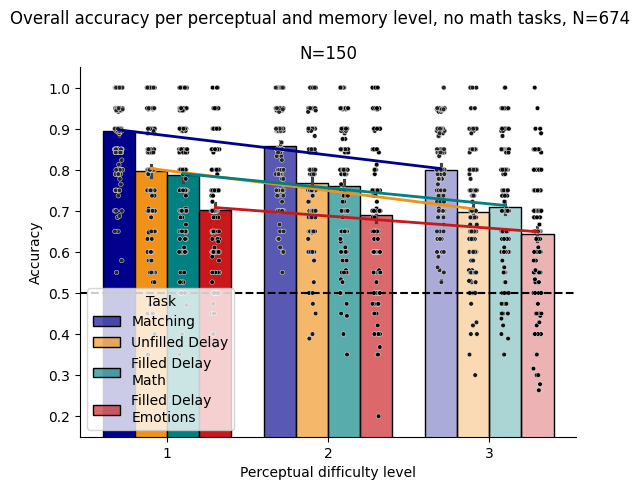

In [21]:
fig, ax = plt.subplots(1,1)

plot_FMP_results_slopes(df_dic['dataset_4'], ax, get_flattened_palette(hue_order_math), hue_order=hue_order_math)
            
plt.suptitle(f"Overall accuracy per perceptual and memory level, no math tasks, N={data.userID.unique().size}", 
             y=1.0)

plt.show()

In [22]:
# Load the dictionary from the pickle file
with open(opj(path_data, 'model_inference_data', 'FMP_math_inference_data_dict.pkl'), 'rb') as f:
    FMP_math_inference_data_dict = pickle.load(f)

{'name': 'Arial'}
Overall accuracy per perceptual and memory level, N=150


../Code/functions/plot_functions.py:190: UserWarning: The palette list has more values (12) than needed (4), which may not be intended.
  bars = sns.barplot(x='difficulty', y='correct_flt', data=data,
../Code/functions/plot_functions.py:195: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:k'` for the same effect.

  stripplot = sns.stripplot(x='difficulty', y='correct_flt',


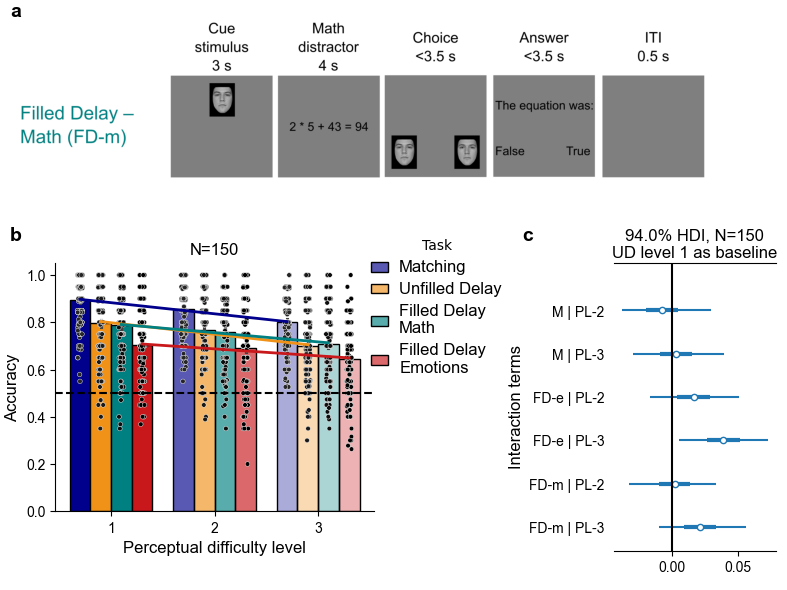

In [23]:
# reset params just in case
plt.rcdefaults()

# to make all stripplots look the same and avoid the random jitter
# https://stackoverflow.com/questions/61944815/how-to-set-seed-for-jitter-in-seaborn-stripplot
np.random.seed(123)

font_size=14
legend_size=10


# CanD
a = 20
b = 15
# rot = 15
c = Canvas(a, b, "cm")


# set font
# c.set_font("Helvetica", size=10)
c.set_font("Arial", size=12, ticksize=legend_size)

# letters
# c.add_text("A", Point(.05, 0.98), weight="bold")
# c.add_text("A)", Point(.02, 0.98), weight="bold", size=font_size)
# c.add_text("A)", Point(.02, 0.98), size=font_size, zorder=10)

c.add_text("a", Point(.02, 0.98), weight="bold", size=font_size, zorder=10)
c.add_text("b", Point(.02, 0.6), weight="bold", size=font_size, zorder=10)
c.add_text("c", Point(.67, 0.6), weight="bold", size=font_size)

           
# titles
titles = [f"Overall accuracy per perceptual and memory level, N={df_dic['dataset_4'].userID.unique().size}"]
# c.add_text(titles[0], Point(.5, 0.96), size=font_size)
for title in titles:
    print(title)

# ### GRID
top_offset = 0.2
bottom_offset = 2
left_offset = 1.4
right_offset = 3.5
img_width = 5
middle_offset = 1.7
middle_v = 13
vsb = 2.6

# method
# ax = c.add_axis("method", Point(0, b-5, "cm"), Point(a-0.5, b, "cm"))
c.add_grid(["method"], 1, Point(0, b-img_width, "cm"),  Point(a-.5,  b-top_offset, "cm"), spacing=Vector(.5, 2.5, "cm"))

# bottom row  
c.add_grid(["FMP_math"], 1, Point(left_offset, bottom_offset, "cm"),  Point(middle_v-right_offset,  b-img_width-middle_offset, "cm"), spacing=Vector(.5, 2.5, "cm"))
c.add_grid(["FMP_math_interaction"], 1, Point(middle_v+vsb, bottom_offset-1, "cm"),  Point(a-0.3,  b-img_width-middle_offset, "cm"), spacing=Vector(.5, 2.5, "cm"))

# plot panel A
c.axes["method"].imshow(plt.imread('./Fig1/FMP_Math_London_high_res_a_smaller_font.png'))
c.axes["method"].axis("off")


# plot panel B
additional_legend_params = {
    'loc':'upper right',
    'bbox_to_anchor':(1.44, 1.15), 
#     'bbox_to_anchor':(.93, 1.2), 
    'handlelength':1.2,
    'frameon': False,
}
plot_FMP_results_slopes(df_dic['dataset_4'], c.ax("FMP_math"), get_flattened_palette(hue_order_math), hue_order=hue_order_math, legend_kwargs=additional_legend_params)

sns.despine(ax=c.ax("FMP_math"))
# add y-axis to start at 0
c.ax("FMP_math").set_ylim(bottom=0)


### plot panel C
N_math = FMP_math_inference_data_dict["correct_flt ~ task + difficulty + (1|userID)"]["posterior"]["userID__factor_dim"].size

az.plot_forest(FMP_math_inference_data_dict['correct_flt ~ task * difficulty + (1|userID)'], 
               var_names=["task:difficulty"], combined=True, ax=c.ax("FMP_math_interaction"))
c.ax("FMP_math_interaction").axvline(0, c='k')

# go over the y ticks to change them and clean them
# to map the abbreviations: retrieve the value associated with the specified key (word.strip()) from the dictionary, 
# if it isn't there, use the word itself
c.ax("FMP_math_interaction").set_yticklabels([
    ' | '.join(dic_task2abbreviations.get(word.strip(), word.strip()) for word in x.get_text().split('[')[1].strip(']').split(','))
    for x in c.ax("FMP_math_interaction").get_yticklabels()
])
c.ax("FMP_math_interaction").set_ylabel('Interaction terms')
# add N to the title
c.ax("FMP_math_interaction").set_title(f'{c.ax("FMP_math_interaction").get_title()}, N={N_math}\nUD level 1 as baseline')


# c.debug_grid(Vector(0.5,0.5,"cm"))

c.show()

c.save(os.path.join(path_figures, "Fig4", 'Figure_4.png'), dpi=300)#, bbox_inches="tight")
c.save(os.path.join(path_figures, "Fig4", 'Figure_4.pdf'), dpi=300)#, bbox_inches="tight")

## Figure 5
[top](#top)

Vege

../Code/functions/plot_functions.py:190: UserWarning: The palette list has more values (12) than needed (4), which may not be intended.
  bars = sns.barplot(x='difficulty', y='correct_flt', data=data,
../Code/functions/plot_functions.py:195: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:k'` for the same effect.

  stripplot = sns.stripplot(x='difficulty', y='correct_flt',


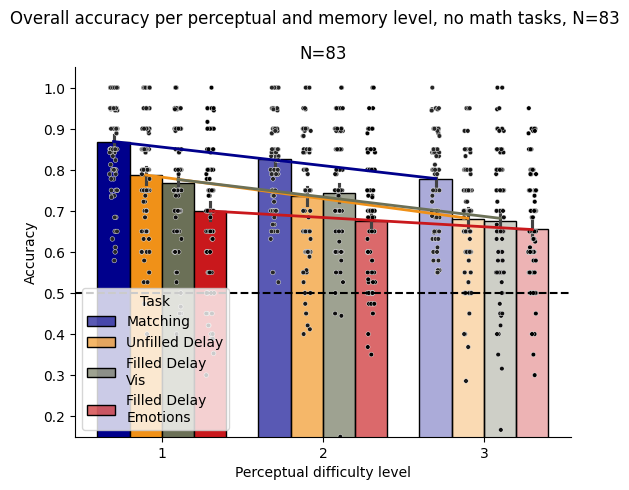

In [24]:
fig, ax = plt.subplots(1,1)

plot_FMP_results_slopes(df_dic['dataset_5'], ax, get_flattened_palette(hue_order_veg), hue_order=hue_order_veg)
            
plt.suptitle(f"Overall accuracy per perceptual and memory level, no math tasks, N={df_dic['dataset_5'].userID.unique().size}", 
             y=1.0)

plt.show()

In [25]:
# Load the dictionary from the pickle file
with open(opj(path_data, 'model_inference_data', 'FMP_vege_inference_data_dict.pkl'), 'rb') as f:
    FMP_vege_inference_data_dict = pickle.load(f)

{'name': 'Arial'}
Overall accuracy per perceptual and memory level, N=83


../Code/functions/plot_functions.py:190: UserWarning: The palette list has more values (12) than needed (4), which may not be intended.
  bars = sns.barplot(x='difficulty', y='correct_flt', data=data,
../Code/functions/plot_functions.py:195: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:k'` for the same effect.

  stripplot = sns.stripplot(x='difficulty', y='correct_flt',


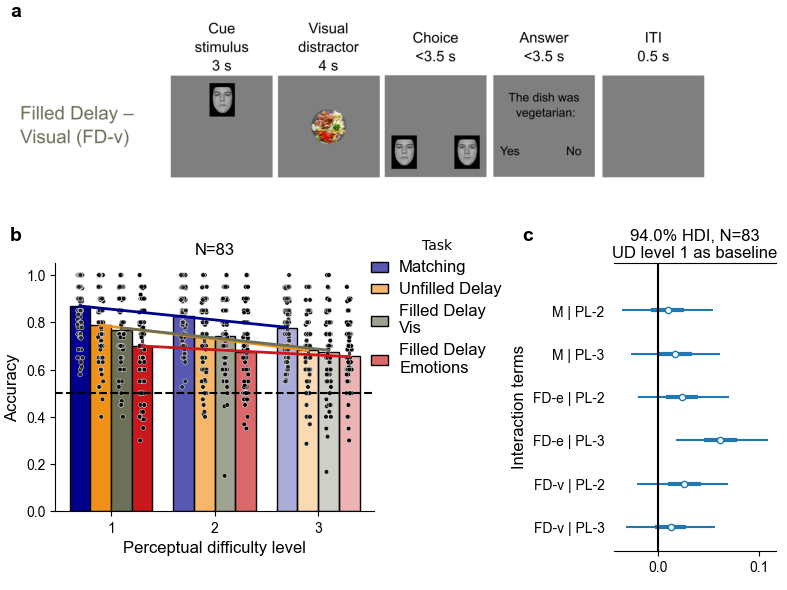

In [26]:
# reset params just in case
plt.rcdefaults()

# to make all stripplots look the same and avoid the random jitter
# https://stackoverflow.com/questions/61944815/how-to-set-seed-for-jitter-in-seaborn-stripplot
np.random.seed(123)

font_size=14
legend_size=10


# CanD
a = 20
b = 15
# rot = 15
c = Canvas(a, b, "cm")


# set font
# c.set_font("Helvetica", size=10)
c.set_font("Arial", size=12, ticksize=legend_size)

# letters
# c.add_text("A", Point(.05, 0.98), weight="bold")
# c.add_text("A)", Point(.02, 0.98), weight="bold", size=font_size)
# c.add_text("A)", Point(.02, 0.98), size=font_size, zorder=10)

c.add_text("a", Point(.02, 0.98), weight="bold", size=font_size, zorder=10)
c.add_text("b", Point(.02, 0.6), weight="bold", size=font_size, zorder=10)
c.add_text("c", Point(.67, 0.6), weight="bold", size=font_size)

           
# titles
titles = [f"Overall accuracy per perceptual and memory level, N={df_dic['dataset_5'].userID.unique().size}"]
# c.add_text(titles[0], Point(.5, 0.96), size=font_size)
for title in titles:
    print(title)

# ### GRID
top_offset = 0.2
bottom_offset = 2
left_offset = 1.4
right_offset = 3.5
img_width = 5
middle_offset = 1.7
middle_v = 13
vsb = 2.6

# method
# ax = c.add_axis("method", Point(0, b-5, "cm"), Point(a-0.5, b, "cm"))
c.add_grid(["method"], 1, Point(0, b-img_width, "cm"),  Point(a-.5,  b-top_offset, "cm"), spacing=Vector(.5, 2.5, "cm"))

# bottom row  
c.add_grid(["FMP_vege"], 1, Point(left_offset, bottom_offset, "cm"),  Point(middle_v-right_offset,  b-img_width-middle_offset, "cm"), spacing=Vector(.5, 2.5, "cm"))
c.add_grid(["FMP_vege_interaction"], 1, Point(middle_v+vsb, bottom_offset-1, "cm"),  Point(a-0.3,  b-img_width-middle_offset, "cm"), spacing=Vector(.5, 2.5, "cm"))

# plot panel A
c.axes["method"].imshow(plt.imread('./Fig1/FMP_vege_London_high_res_c_smaller_font.png'))
c.axes["method"].axis("off")


# plot panel B
additional_legend_params = {
    'loc':'upper right',
    'bbox_to_anchor':(1.44, 1.15), 
#     'bbox_to_anchor':(.93, 1.2), 
    'handlelength':1.2,
    'frameon': False,
}
plot_FMP_results_slopes(df_dic['dataset_5'], c.ax("FMP_vege"), get_flattened_palette(hue_order_veg), hue_order=hue_order_veg, legend_kwargs=additional_legend_params)

sns.despine(ax=c.ax("FMP_vege"))
# add y-axis to start at 0
c.ax("FMP_vege").set_ylim(bottom=0)


### plot panel C
N_vege = FMP_vege_inference_data_dict["correct_flt ~ task + difficulty + (1|userID)"]["posterior"]["userID__factor_dim"].size

az.plot_forest(FMP_vege_inference_data_dict['correct_flt ~ task * difficulty + (1|userID)'], 
               var_names=["task:difficulty"], combined=True, ax=c.ax("FMP_vege_interaction"))
c.ax("FMP_vege_interaction").axvline(0, c='k')

# go over the y ticks to change them and clean them
# to map the abbreviations: retrieve the value associated with the specified key (word.strip()) from the dictionary, 
# if it isn't there, use the word itself
c.ax("FMP_vege_interaction").set_yticklabels([
    ' | '.join(dic_task2abbreviations.get(word.strip(), word.strip()) for word in x.get_text().split('[')[1].strip(']').split(','))
    for x in c.ax("FMP_vege_interaction").get_yticklabels()
])
c.ax("FMP_vege_interaction").set_ylabel('Interaction terms')
# add N to the title
c.ax("FMP_vege_interaction").set_title(f'{c.ax("FMP_vege_interaction").get_title()}, N={N_vege}\nUD level 1 as baseline')


# c.debug_grid(Vector(0.5,0.5,"cm"))

c.show()

c.save(os.path.join(path_figures, "Fig5", 'Figure_5.png'), dpi=300)#, bbox_inches="tight")
c.save(os.path.join(path_figures, "Fig5", 'Figure_5.pdf'), dpi=300)#, bbox_inches="tight")

## Figure 6
[top](#top)

Inversion in UD

In [27]:
# add target location -- if it was the original
df_dic["dataset_6"]["target_loc_simple"] = (df_dic["dataset_6"]["target"].str.contains('-0p.png')).map({True:"target_0", False:"other"})
df_dic["dataset_6"]["target_loc"] = df_dic["dataset_6"].target.str.split('_').str[-1].str.split('.').str[0].str.split('-').str[-1]

In [28]:
df_dic['dataset_6']

,inverted,stim1,stim2,target,RT,userID,order,correct_check,difficulty,levels,correct_flt,task,Experiment,target_loc_simple,target_loc
0,True,invert_sharp_CFD-WM-212-097-N_m4018-0p.png,invert_sharp_CFD-WM-212-097-N_m4018-36p.png,invert_sharp_CFD-WM-212-097-N_m4018-0p.png,NaN,s_1079,1,NaN,1,36,NaN,Unfilled Delay,dataset_6,target_0,0p
1,True,invert_sharp_BFD-M-6_m4018-24p.png,invert_sharp_BFD-M-6_m4018-0p.png,invert_sharp_BFD-M-6_m4018-0p.png,3403.800,s_1079,1,True,3,24,1.0,Unfilled Delay,dataset_6,target_0,0p
2,True,invert_sharp_CFD-BF-051-035-N_AF01NES-0p.png,invert_sharp_CFD-BF-051-035-N_AF01NES-24p.png,invert_sharp_CFD-BF-051-035-N_AF01NES-0p.png,2978.440,s_1079,1,True,3,24,1.0,Unfilled Delay,dataset_6,target_0,0p
3,True,invert_sharp_CFD-WM-203-023-N_m4018-0p.png,invert_sharp_CFD-WM-203-023-N_m4018-36p.png,invert_sharp_CFD-WM-203-023-N_m4018-36p.png,NaN,s_1079,1,NaN,1,36,NaN,Unfilled Delay,dataset_6,other,36p
4,True,invert_sharp_CFD-WF-225-101-N_AF01NES-24p.png,invert_sharp_CFD-WF-225-101-N_AF01NES-0p.png,invert_sharp_CFD-WF-225-101-N_AF01NES-24p.png,1473.080,s_1079,1,True,3,24,1.0,Unfilled Delay,dataset_6,other,24p
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17035,False,sharp_CFD-BM-216-088-N_m4018-24p.png,sharp_CFD-BM-216-088-N_m4018-0p.png,sharp_CFD-BM-216-088-N_m4018-24p.png,1569.441,s_656,12,False,3,24,0.0,Unfilled Delay,dataset_6,other,24p
17036,False,sharp_London-M-119-03_m4018-0p.png,sharp_London-M-119-03_m4018-36p.png,sharp_London-M-119-03_m4018-0p.png,998.522,s_656,12,True,1,36,1.0,Unfilled Delay,dataset_6,target_0,0p
17037,False,sharp_BFD-M-356_m4018-0p.png,sharp_BFD-M-356_m4018-36p.png,sharp_BFD-M-356_m4018-0p.png,2716.751,s_656,12,True,1,36,1.0,Unfilled Delay,dataset_6,target_0,0p
17038,False,sharp_BFD-F-65_AF01NES-30p.png,sharp_BFD-F-65_AF01NES-0p.png,sharp_BFD-F-65_AF01NES-0p.png,1478.633,s_656,12,True,2,30,1.0,Unfilled Delay,dataset_6,target_0,0p


In [29]:
# Check with 2 way ANOVA

d = df_dic['dataset_6'].groupby(["userID","inverted","difficulty"]).correct_flt.mean().reset_index().copy()


aov = pg.anova(data=d, 
               dv='correct_flt', between=['inverted', 'difficulty'],
             detailed=True)

aov['star_gazing'] = aov['p-unc'].apply(star_gazing)

aov#.round(4)

,Source,SS,DF,MS,F,p-unc,np2,star_gazing
0,inverted,0.705115,1,0.705115,62.570855,2.298898e-14,0.129661,***
1,difficulty,0.455854,2,0.227927,20.225907,4.108387e-09,0.087852,***
2,inverted * difficulty,0.073789,2,0.036895,3.273986,3.882360e-02,0.015351,*
3,Residual,4.733004,420,0.011269,NaN,NaN,NaN,


In [30]:
# Post-hoc pairwise comparisons for inverted
posthoc_inverted = pg.pairwise_tukey(data=d, dv='correct_flt', between='inverted')
posthoc_inverted['star_gazing'] = posthoc_inverted['p-tukey'].apply(star_gazing)
print("Post-hoc comparisons for inverted:")
# print(posthoc_inverted)
display(posthoc_inverted)

# Post-hoc pairwise comparisons for difficulty
posthoc_difficulty = pg.pairwise_tukey(data=d, dv='correct_flt', between='difficulty', effsize='cohen')
posthoc_difficulty['star_gazing'] = posthoc_difficulty['p-tukey'].apply(star_gazing)
print("\nPost-hoc comparisons for difficulty:")
# print(posthoc_difficulty)
posthoc_difficulty

Post-hoc comparisons for inverted:


,A,B,mean(A),mean(B),diff,se,T,p-tukey,hedges,star_gazing
0,False,True,0.71777,0.636402,0.081368,0.010796,7.53721,4.444223e-13,0.729065,***



Post-hoc comparisons for difficulty:


,A,B,mean(A),mean(B),diff,se,T,p-tukey,cohen,star_gazing
0,1,2,0.720120,0.670273,0.049847,0.013547,3.679474,7.700502e-04,0.412921,***
1,1,3,0.720120,0.640866,0.079254,0.013547,5.850195,2.950112e-08,0.691503,***
2,2,3,0.670273,0.640866,0.029407,0.013547,2.170721,7.744354e-02,0.275630,


{'name': 'Arial'}
Accuracy in UD in inversion experiment, shown is SEM
Inversion effect for Unfilled Delay, N=71


/var/folders/bx/tb4883l53hdd3zp2y0nyy_4m0000gp/T/ipykernel_83736/1498011454.py:60: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:k'` for the same effect.

  stripplot = sns.stripplot(x='difficulty', y='correct_flt',


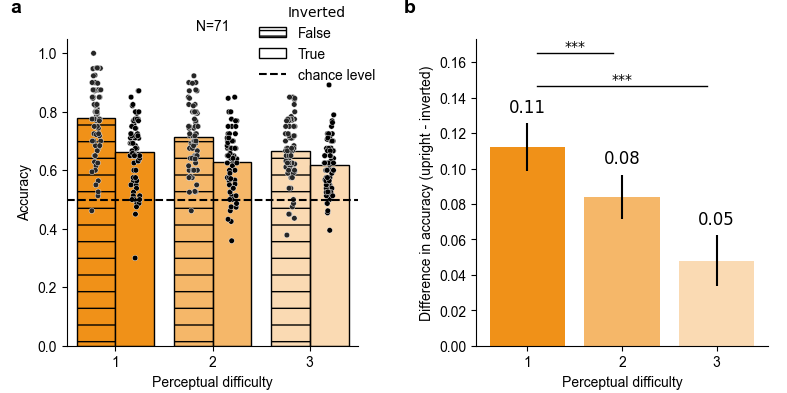

In [31]:
# define canvas

from cand import Canvas, Vector, Point

# reset params just in case
plt.rcdefaults()

# to make all stripplots look the same and avoid the random jitter
# https://stackoverflow.com/questions/61944815/how-to-set-seed-for-jitter-in-seaborn-stripplot
np.random.seed(123)

font_size=14
legend_size=10


# CanD
a = 20
b = 10
# rot = 15
c = Canvas(a, b, "cm")

# set font
c.set_font("Arial", size=10)

# letters
# c.add_text("A)", Point(.02, 0.97), weight="bold", size=font_size)
# c.add_text("A)", Point(.02, 0.97), size=font_size)
c.add_text("a", Point(.02, 0.98), weight="bold", size=font_size)
c.add_text("b", Point(.52, 0.98), weight="bold", size=font_size)
           
# titles
titles = ["Accuracy in UD in inversion experiment, shown is SEM", f"Inversion effect for Unfilled Delay, N={df_dic['dataset_6'].userID.unique().size}"]
# c.add_text(titles[0], Point(.55, 0.97), size=font_size)
for title in titles:
    print(title)


left_offset = 1.7
top_offset = 1
# middle_bottom = 9
# hspace_between_plots = 2.8
bottom_offset = 1.2

hsb=1
vsb=3

# ### GRID
# # top row
c.add_grid(["acc_dataset_6","inversion_effect"], 1, Point(left_offset, bottom_offset, "cm"), Point(a-.5, b-top_offset, "cm"), spacing=Vector(vsb, hsb, "cm"), unitname="grid")


### Plot
# plot bars and add individual points
bars = sns.barplot(x='difficulty', y='correct_flt', data=df_dic["dataset_6"], errorbar='se',
                   hue='inverted',
                   edgecolor='k',
                   ax=c.ax("acc_dataset_6"),
                   )

stripplot = sns.stripplot(x='difficulty', y='correct_flt',
                          hue='inverted', dodge=True,
                          data=df_dic["dataset_6"].groupby(['userID', 'inverted', 'difficulty']).correct_flt.mean().reset_index(),
                          edgecolor='w', color='k',
                          ax=c.ax("acc_dataset_6"), size=4, linewidth=0.3, legend=False,
                          )

## hatching
#     hatches = ['-', '+', 'x', '\\', '*', '.']
hatches = ['-']

for (j,hatch_pattern), these_bars in zip(enumerate(hatches), c.ax("acc_dataset_6").containers):
    for this_bar in these_bars:
        this_bar.set_hatch(hatch_pattern)

# add chance level line
c.ax("acc_dataset_6").axhline(0.5, c='k', linestyle="--", label='chance level', zorder=4)

# repaint the bars
for i, bar in enumerate(bars.patches):
    bar.set_facecolor(get_flattened_palette(['delay'])[i%3])
    
# # repaint the points
# for i, point in enumerate(stripplot.collections):
#     point.set_facecolor(get_flattened_palette(['delay'])[i//2])


# legend, https://stackoverflow.com/questions/53849888/make-patches-bigger-used-as-legend-inside-matplotlib
leg = c.ax("acc_dataset_6").legend(title='Inverted', loc='upper right', frameon=False, bbox_to_anchor=(1.1,1.15))

# make the legend to be squares
for j,patch in enumerate(leg.get_patches()):
#             patch.set_height(16)
#             patch.set_width(16)
#             patch.set_x(43)
    #set colour and hatch
    patch.set_facecolor('w')
    if j==0:
        patch.set_hatch(3 * hatch_pattern)

c.ax("acc_dataset_6").set_ylabel('Accuracy')
c.ax("acc_dataset_6").set_xlabel('Perceptual difficulty')
c.ax("acc_dataset_6").set_title(f"N={df_dic['dataset_6'].userID.unique().size}")
        


#### Plot inversion effect
barplot_inv = c.ax("inversion_effect").bar(["1", "2", "3"],
       [
           (df_dic["dataset_6"][(df_dic["dataset_6"]["inverted"]==False)&(df_dic["dataset_6"]["levels"]==36)].groupby(["userID"]).correct_flt.mean()-df_dic["dataset_6"][(df_dic["dataset_6"]["inverted"]==True)&(df_dic["dataset_6"]["levels"]==36)].groupby(["userID"]).correct_flt.mean()).mean(),
           #
           (df_dic["dataset_6"][(df_dic["dataset_6"]["inverted"]==False)&(df_dic["dataset_6"]["levels"]==30)].groupby(["userID"]).correct_flt.mean()-df_dic["dataset_6"][(df_dic["dataset_6"]["inverted"]==True)&(df_dic["dataset_6"]["levels"]==30)].groupby(["userID"]).correct_flt.mean()).mean(),
           #
           (df_dic["dataset_6"][(df_dic["dataset_6"]["inverted"]==False)&(df_dic["dataset_6"]["levels"]==24)].groupby(["userID"]).correct_flt.mean()-df_dic["dataset_6"][(df_dic["dataset_6"]["inverted"]==True)&(df_dic["dataset_6"]["levels"]==24)].groupby(["userID"]).correct_flt.mean()).mean(),

       ],
        # plot SEM
            yerr=[
           (df_dic["dataset_6"][(df_dic["dataset_6"]["inverted"]==False)&(df_dic["dataset_6"]["levels"]==24)].groupby(["userID"]).correct_flt.mean()-df_dic["dataset_6"][(df_dic["dataset_6"]["inverted"]==True)&(df_dic["dataset_6"]["levels"]==36)].groupby(["userID"]).correct_flt.mean()).sem(),
           #
           (df_dic["dataset_6"][(df_dic["dataset_6"]["inverted"]==False)&(df_dic["dataset_6"]["levels"]==30)].groupby(["userID"]).correct_flt.mean()-df_dic["dataset_6"][(df_dic["dataset_6"]["inverted"]==True)&(df_dic["dataset_6"]["levels"]==30)].groupby(["userID"]).correct_flt.mean()).sem(),
           #
           (df_dic["dataset_6"][(df_dic["dataset_6"]["inverted"]==False)&(df_dic["dataset_6"]["levels"]==36)].groupby(["userID"]).correct_flt.mean()-df_dic["dataset_6"][(df_dic["dataset_6"]["inverted"]==True)&(df_dic["dataset_6"]["levels"]==24)].groupby(["userID"]).correct_flt.mean()).sem(),   
            ],           
            
          color=get_flattened_palette(['delay'])
       )

# https://matplotlib.org/stable/gallery/lines_bars_and_markers/bar_label_demo.html
c.ax("inversion_effect").bar_label(barplot_inv, fmt='%0.2f', padding=5, size=12)    
   
    
c.ax("inversion_effect").set_ylabel('Difference in accuracy (upright - inverted)')
c.ax("inversion_effect").set_xlabel('Perceptual difficulty')
# plt.setp(c.ax("inversion_effect").get_xticklabels(), rotation=rot, horizontalalignment='right', size=10)


## add significance
for idx, row in posthoc_difficulty.iterrows():
    # plot only significant
    if row['p-tukey']<0.05:
        plot_significance_pairs(row['A']-1,#np.where(c.ax(f"d_prime_{i}").get_xticklabels() == row['A'])[0],
                                row['B']-1, 
                                row['p-tukey'], c.ax("inversion_effect"), yerr=True, dh=-0.45, barh=0, x_offset=0.1)




for ax in c.axes.values():
    sns.despine(ax=ax)


# c.debug_grid(Vector(0.5,0.5,"cm"))
c.show()
#
# c.save(os.path.join(path_figures, "Fig5", 'Figure_6.png'), dpi=300)#, bbox_inches="tight")
# c.save(os.path.join(path_figures, "Fig5", 'Figure_6.pdf'), dpi=300)#, bbox_inches="tight")

#### Unequal panels


{'name': 'Arial'}
Accuracy in UD in inversion experiment, shown is SEM
Inversion effect for Unfilled Delay, N=71


/var/folders/bx/tb4883l53hdd3zp2y0nyy_4m0000gp/T/ipykernel_83736/1355070728.py:62: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:k'` for the same effect.

  stripplot = sns.stripplot(x='difficulty', y='correct_flt',


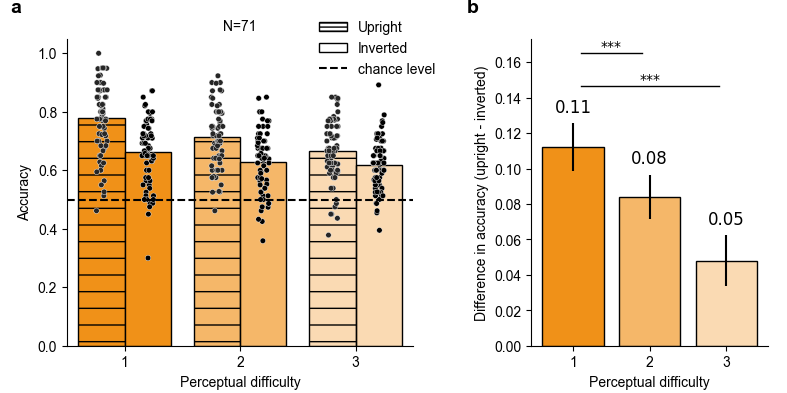

In [32]:
# define canvas

from cand import Canvas, Vector, Point

# reset params just in case
plt.rcdefaults()

# to make all stripplots look the same and avoid the random jitter
# https://stackoverflow.com/questions/61944815/how-to-set-seed-for-jitter-in-seaborn-stripplot
np.random.seed(123)

font_size=14
legend_size=10


# CanD
a = 20
b = 10
# rot = 15
c = Canvas(a, b, "cm")

# set font
c.set_font("Arial", size=10)

# letters
# c.add_text("A)", Point(.02, 0.97), weight="bold", size=font_size)
# c.add_text("A)", Point(.02, 0.97), size=font_size)
c.add_text("a", Point(.02, 0.98), weight="bold", size=font_size)
c.add_text("b", Point(.6, 0.98), weight="bold", size=font_size)
           
# titles
titles = ["Accuracy in UD in inversion experiment, shown is SEM", f"Inversion effect for Unfilled Delay, N={df_dic['dataset_6'].userID.unique().size}"]
# c.add_text(titles[0], Point(.55, 0.97), size=font_size)
for title in titles:
    print(title)


left_offset = 1.7
top_offset = 1
middle = 12
# hspace_between_plots = 2.8
bottom_offset = 1.2

hsb=1
vsb=3

# ### GRID
# # top row
# c.add_grid(["acc_dataset_6","inversion_effect"], 1, Point(left_offset, bottom_offset, "cm"), Point(a-.5, b-top_offset, "cm"), spacing=Vector(vsb, hsb, "cm"), unitname="grid")
c.add_grid(["acc_dataset_6"], 1, Point(left_offset, bottom_offset, "cm"), Point(middle-vsb/2, b-top_offset, "cm"), spacing=Vector(vsb, hsb, "cm"), unitname="grid")
c.add_grid(["inversion_effect"], 1, Point(middle+vsb/2, bottom_offset, "cm"), Point(a-.5, b-top_offset, "cm"), spacing=Vector(vsb, hsb, "cm"))


### Plot
# plot bars and add individual points
bars = sns.barplot(x='difficulty', y='correct_flt', data=df_dic["dataset_6"], errorbar='se',
                   hue='inverted',
                   edgecolor='k',
                   ax=c.ax("acc_dataset_6"),
                   )

stripplot = sns.stripplot(x='difficulty', y='correct_flt',
                          hue='inverted', dodge=True,
                          data=df_dic["dataset_6"].groupby(['userID', 'inverted', 'difficulty']).correct_flt.mean().reset_index(),
                          edgecolor='w', color='k',
                          ax=c.ax("acc_dataset_6"), size=4, linewidth=0.3, legend=False,
                          )

## hatching
#     hatches = ['-', '+', 'x', '\\', '*', '.']
hatches = ['-']

for (j,hatch_pattern), these_bars in zip(enumerate(hatches), c.ax("acc_dataset_6").containers):
    for this_bar in these_bars:
        this_bar.set_hatch(hatch_pattern)

# add chance level line
c.ax("acc_dataset_6").axhline(0.5, c='k', linestyle="--", label='chance level', zorder=4)

# repaint the bars
for i, bar in enumerate(bars.patches):
    bar.set_facecolor(get_flattened_palette(['delay'])[i%3])
    
# # repaint the points
# for i, point in enumerate(stripplot.collections):
#     point.set_facecolor(get_flattened_palette(['delay'])[i//2])


# legend, https://stackoverflow.com/questions/53849888/make-patches-bigger-used-as-legend-inside-matplotlib
# leg = c.ax("acc_dataset_6").legend(title='Inverted', loc='upper right', frameon=False, bbox_to_anchor=(1.1,1.1))
handles, labels = c.ax("acc_dataset_6").get_legend_handles_labels()
leg = c.ax("acc_dataset_6").legend(handles, [x.replace('True', 'Inverted').replace('False', 'Upright') for x in labels], loc='upper right', frameon=False, bbox_to_anchor=(1.1,1.1))

# make the legend to be squares
for j,patch in enumerate(leg.get_patches()):
#             patch.set_height(16)
#             patch.set_width(16)
#             patch.set_x(43)
    #set colour and hatch
    patch.set_facecolor('w')
    if j==0:
        patch.set_hatch(4*hatch_pattern)

c.ax("acc_dataset_6").set_ylabel('Accuracy')
c.ax("acc_dataset_6").set_xlabel('Perceptual difficulty')
c.ax("acc_dataset_6").set_title(f"N={df_dic['dataset_6'].userID.unique().size}")
        


#### Plot inversion effect
barplot_inv = c.ax("inversion_effect").bar(["1", "2", "3"],
       [
           (df_dic["dataset_6"][(df_dic["dataset_6"]["inverted"]==False)&(df_dic["dataset_6"]["levels"]==36)].groupby(["userID"]).correct_flt.mean()-df_dic["dataset_6"][(df_dic["dataset_6"]["inverted"]==True)&(df_dic["dataset_6"]["levels"]==36)].groupby(["userID"]).correct_flt.mean()).mean(),
           #
           (df_dic["dataset_6"][(df_dic["dataset_6"]["inverted"]==False)&(df_dic["dataset_6"]["levels"]==30)].groupby(["userID"]).correct_flt.mean()-df_dic["dataset_6"][(df_dic["dataset_6"]["inverted"]==True)&(df_dic["dataset_6"]["levels"]==30)].groupby(["userID"]).correct_flt.mean()).mean(),
           #
           (df_dic["dataset_6"][(df_dic["dataset_6"]["inverted"]==False)&(df_dic["dataset_6"]["levels"]==24)].groupby(["userID"]).correct_flt.mean()-df_dic["dataset_6"][(df_dic["dataset_6"]["inverted"]==True)&(df_dic["dataset_6"]["levels"]==24)].groupby(["userID"]).correct_flt.mean()).mean(),

       ],
        # plot SEM
            yerr=[
           (df_dic["dataset_6"][(df_dic["dataset_6"]["inverted"]==False)&(df_dic["dataset_6"]["levels"]==24)].groupby(["userID"]).correct_flt.mean()-df_dic["dataset_6"][(df_dic["dataset_6"]["inverted"]==True)&(df_dic["dataset_6"]["levels"]==36)].groupby(["userID"]).correct_flt.mean()).sem(),
           #
           (df_dic["dataset_6"][(df_dic["dataset_6"]["inverted"]==False)&(df_dic["dataset_6"]["levels"]==30)].groupby(["userID"]).correct_flt.mean()-df_dic["dataset_6"][(df_dic["dataset_6"]["inverted"]==True)&(df_dic["dataset_6"]["levels"]==30)].groupby(["userID"]).correct_flt.mean()).sem(),
           #
           (df_dic["dataset_6"][(df_dic["dataset_6"]["inverted"]==False)&(df_dic["dataset_6"]["levels"]==36)].groupby(["userID"]).correct_flt.mean()-df_dic["dataset_6"][(df_dic["dataset_6"]["inverted"]==True)&(df_dic["dataset_6"]["levels"]==24)].groupby(["userID"]).correct_flt.mean()).sem(),   
            ],           
            
          color=get_flattened_palette(['delay']), edgecolor='k',
       )

# https://matplotlib.org/stable/gallery/lines_bars_and_markers/bar_label_demo.html
c.ax("inversion_effect").bar_label(barplot_inv, fmt='%0.2f', padding=5, size=12)    
   
    
c.ax("inversion_effect").set_ylabel('Difference in accuracy (upright - inverted)')
c.ax("inversion_effect").set_xlabel('Perceptual difficulty')
# plt.setp(c.ax("inversion_effect").get_xticklabels(), rotation=rot, horizontalalignment='right', size=10)


## add significance
for idx, row in posthoc_difficulty.iterrows():
    # plot only significant
    if row['p-tukey']<0.05:
        plot_significance_pairs(row['A']-1,#np.where(c.ax(f"d_prime_{i}").get_xticklabels() == row['A'])[0],
                                row['B']-1, 
                                row['p-tukey'], c.ax("inversion_effect"), yerr=True, dh=-0.45, barh=0, x_offset=0.1)


for ax in c.axes.values():
    sns.despine(ax=ax)


# c.debug_grid(Vector(0.5,0.5,"cm"))
c.show()
#
c.save(os.path.join(path_figures, "Fig6", 'Figure_6.png'), dpi=300)#, bbox_inches="tight")
c.save(os.path.join(path_figures, "Fig6", 'Figure_6.pdf'), dpi=300)#, bbox_inches="tight")

## Figure 7
[top](#top)

Long-term recognition memory

In [33]:
# load all dataframes
df_dic_mem = {}

# for file in os.listdir(path_datasets):
for file in ['FMP_memory_dataset_1b.csv', 'FMP_memory_dataset_2.csv', 'FMP_memory_dataset_3.csv']:
    f = file.replace('FMP_memory_', '').replace('.csv', '')
    df_dic_mem[f] = pd.read_csv(os.path.join(path_datasets, file))
    
    df_dic_mem[f]["Experiment"] = f
        

    # clean
    df_dic_mem[f].reset_index(drop=True, inplace=True)
    
    if 'Unnamed: 0' in df_dic_mem[f].columns:
        df_dic_mem[f].drop('Unnamed: 0', inplace=True, axis=1)

### Compute d'
[top](#top)

In [34]:
# First we need to deal with randomised matched S experiment where there are not the same 
# numbers of old/new stimuli per participant, so the ratios has to be computed separately

# Group the data by userID and familiarity
grouped_data = df_dic_mem['dataset_2'].loc[
    ~df_dic_mem['dataset_2']['familiarity'].isna(),
    ['familiarity', 'userID']
].groupby(['userID', 'familiarity']).size().unstack(fill_value=0)

# Initialize a dictionary to store the results
df_results_dprime = pd.DataFrame({})

# Iterate over each userID
for userID in grouped_data.index:
    c = grouped_data.loc[userID, 'old']
    d = grouped_data.loc[userID, 'new']
    a = c / (c + d)
    b = d / (c + d)
    
    # Apply the calculate_d_prime function
    result = calculate_d_prime(
        df_dic_mem['dataset_2'].loc[(~df_dic_mem['dataset_2']['familiarity'].isna())&(df_dic_mem['dataset_2']['userID']==userID)],
        a, b, c, d, col='correct_memory_check_flt', c=True, beta=True
    )
    
    # Store the result for the current userID
    df_results_dprime = pd.concat([df_results_dprime, pd.DataFrame(result)])
#     df_results_dprime['userID'] = userID

df_results_dprime.reset_index(inplace=True)

df_results_dprime['task'] = 'dataset_2'


# add all tasks
for f in ['dataset_1b', 'dataset_3']:
    tmp = pd.DataFrame(
        calculate_d_prime(df_dic_mem[f].loc[(~df_dic_mem[f]['familiarity'].isna())&(df_dic_mem[f]['task'] =='memory-confidence')], 
                      0.5, 0.5, 30, 30, col='correct_memory_check_flt', c=True, beta=True)
    ).reset_index()
    tmp['task'] = f
    
    df_results_dprime = pd.concat([df_results_dprime,tmp])

df_results_dprime.reset_index(inplace=True, drop=True)

df_results_dprime


,userID,d_prime,beta,c,task
0,s_1005,1.124047,0.848613,-0.146036,dataset_2
1,s_1017,0.652092,0.916716,-0.133352,dataset_2
2,s_1022,2.901616,7.413085,0.690390,dataset_2
3,s_1023,0.117196,0.929174,-0.626808,dataset_2
4,s_1030,0.542591,1.059575,0.106651,dataset_2
...,...,...,...,...,...
591,s_980,0.000000,1.000000,0.245006,dataset_3
592,s_99,1.292179,0.481781,-0.565142,dataset_3
593,s_991,0.407436,1.016965,0.041288,dataset_3
594,s_996,0.835225,1.076557,0.088321,dataset_3


#### Map the first task on the data
[top](#top)

In [35]:
df_user_task_dict = pd.DataFrame()

for i,f in enumerate(df_results_dprime.task.unique()):
    if f=='PB13':
        order=18
    else:
        order=1
    # get the first task per user
    user_task_dict = df_dic[f].loc[df_dic[f]["order"]==order].groupby('userID')['task'].first()
    
    df_user_task_dict = pd.concat([df_user_task_dict,user_task_dict])
    
df_results_dprime['first_task'] = df_results_dprime['userID'].map(df_user_task_dict.to_dict()[0]).replace('perc', 'perception')

# check
df_results_dprime[df_results_dprime['first_task'].isna()]

,userID,d_prime,beta,c,task,first_task


In [36]:
df_results_dprime

,userID,d_prime,beta,c,task,first_task
0,s_1005,1.124047,0.848613,-0.146036,dataset_2,Unfilled Delay
1,s_1017,0.652092,0.916716,-0.133352,dataset_2,Filled Delay - emotions
2,s_1022,2.901616,7.413085,0.690390,dataset_2,Unfilled Delay
3,s_1023,0.117196,0.929174,-0.626808,dataset_2,Unfilled Delay
4,s_1030,0.542591,1.059575,0.106651,dataset_2,Matching
...,...,...,...,...,...,...
591,s_980,0.000000,1.000000,0.245006,dataset_3,Matching
592,s_99,1.292179,0.481781,-0.565142,dataset_3,Matching
593,s_991,0.407436,1.016965,0.041288,dataset_3,Matching
594,s_996,0.835225,1.076557,0.088321,dataset_3,Unfilled Delay


---

#### stats d'
[top](#top)

In [37]:
df_results_dprime.loc[~df_results_dprime['first_task'].isin(hue_order)]

,userID,d_prime,beta,c,task,first_task


In [38]:
aov = pg.anova(data=df_results_dprime, 
               dv='d_prime', between=['first_task'], detailed=True)
aov['star_gazing'] = aov['p-unc'].apply(star_gazing)

aov

,Source,SS,DF,MS,F,p-unc,np2,star_gazing
0,first_task,5.471314,2,2.735657,12.624188,0.000004,0.040839,***
1,Within,128.502888,593,0.216700,NaN,NaN,NaN,


In [39]:
# Post-hoc pairwise comparisons for task
posthoc_task = pg.pairwise_tukey(data=df_results_dprime, dv='d_prime', between='first_task', effsize='cohen')
posthoc_task['star_gazing'] = posthoc_task['p-tukey'].apply(star_gazing)
print("\nPost-hoc comparisons for task:")
# print(posthoc_task)
posthoc_task


Post-hoc comparisons for task:


,A,B,mean(A),mean(B),diff,se,T,p-tukey,cohen,star_gazing
0,Filled Delay - emotions,Matching,0.697476,0.658443,0.039033,0.046926,0.831791,0.683415,0.087299,
1,Filled Delay - emotions,Unfilled Delay,0.697476,0.876988,-0.179513,0.046982,-3.820872,0.000431,-0.378476,***
2,Matching,Unfilled Delay,0.658443,0.876988,-0.218545,0.046263,-4.723987,0.000009,-0.460722,***


#### tasks

In [40]:
from IPython.display import display
# experiment2use = ['standalone', 'matched_concat2', 'longitudinal_1']
experiment2use = ['dataset_1b', 'dataset_2', 'dataset_3']

for i,t in enumerate(experiment2use):
    aov = pg.anova(data=df_results_dprime.loc[df_results_dprime["task"]==t], 
               dv='d_prime', between=['first_task'], detailed=True)
    aov['star_gazing'] = aov['p-unc'].apply(star_gazing)

    print(t)
    display(aov)
    


dataset_1b


,Source,SS,DF,MS,F,p-unc,np2,star_gazing
0,first_task,3.010922,2,1.505461,7.373212,0.000837,0.076112,***
1,Within,36.548188,179,0.204180,NaN,NaN,NaN,


dataset_2


,Source,SS,DF,MS,F,p-unc,np2,star_gazing
0,first_task,0.121057,2,0.060529,0.253561,0.776366,0.003392,
1,Within,35.568350,149,0.238714,NaN,NaN,NaN,


dataset_3


,Source,SS,DF,MS,F,p-unc,np2,star_gazing
0,first_task,3.864782,2,1.932391,9.336451,0.000122,0.067248,***
1,Within,53.605940,259,0.206973,NaN,NaN,NaN,


In [41]:
significance_dprime_dic = {}

# Post-hoc pairwise comparisons for task
for i,t in enumerate(experiment2use):
    
    posthoc_task = pg.pairwise_tukey(data=df_results_dprime.loc[df_results_dprime["task"]==t], 
                                     dv='d_prime', between='first_task', effsize='cohen')
    posthoc_task['star_gazing'] = posthoc_task['p-tukey'].apply(star_gazing)
    print(f"\nPost-hoc comparisons for task in {t}:")
    display(posthoc_task)
    
    # save it
    significance_dprime_dic[t] = posthoc_task
    
    
# add the main
posthoc_task = pg.pairwise_tukey(data=df_results_dprime, dv='d_prime', between='first_task')
posthoc_task['star_gazing'] = posthoc_task['p-tukey'].apply(star_gazing)
significance_dprime_dic["d_prime_all"] = posthoc_task


Post-hoc comparisons for task in dataset_1b:


,A,B,mean(A),mean(B),diff,se,T,p-tukey,cohen,star_gazing
0,Filled Delay - emotions,Matching,0.622498,0.557977,0.064521,0.086565,0.745344,0.736827,0.149736,
1,Filled Delay - emotions,Unfilled Delay,0.622498,0.847379,-0.224881,0.081105,-2.772705,0.016843,-0.502468,*
2,Matching,Unfilled Delay,0.557977,0.847379,-0.289402,0.080681,-3.587013,0.001249,-0.611825,**



Post-hoc comparisons for task in dataset_2:


,A,B,mean(A),mean(B),diff,se,T,p-tukey,cohen,star_gazing
0,Filled Delay - emotions,Matching,0.792257,0.803949,-0.011692,0.093631,-0.124873,0.991441,-0.025450,
1,Filled Delay - emotions,Unfilled Delay,0.792257,0.859950,-0.067693,0.100277,-0.675059,0.778350,-0.128264,
2,Matching,Unfilled Delay,0.803949,0.859950,-0.056001,0.099067,-0.565286,0.838745,-0.116609,



Post-hoc comparisons for task in dataset_3:


,A,B,mean(A),mean(B),diff,se,T,p-tukey,cohen,star_gazing
0,Filled Delay - emotions,Matching,0.685873,0.629935,0.055938,0.068656,0.814752,0.694226,0.127849,
1,Filled Delay - emotions,Unfilled Delay,0.685873,0.910641,-0.224768,0.069790,-3.220639,0.004107,-0.487073,**
2,Matching,Unfilled Delay,0.629935,0.910641,-0.280706,0.068238,-4.113652,0.000154,-0.603103,***


{'name': 'Arial'}
Accuracy per task
d' per task
Overal accuracy
Overall d'


/var/folders/bx/tb4883l53hdd3zp2y0nyy_4m0000gp/T/ipykernel_83736/3250174627.py:74: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  stripplot = sns.stripplot(data=data, y='d_prime', x='first_task',
/var/folders/bx/tb4883l53hdd3zp2y0nyy_4m0000gp/T/ipykernel_83736/3250174627.py:74: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  stripplot = sns.stripplot(data=data, y='d_prime', x='first_task',
/var/folders/bx/tb4883l53hdd3zp2y0nyy_4m0000gp/T/ipykernel_83736/3250174627.py:74: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  stripplot = sns.stripplot(data=data, y='d_prime', x='first_task'

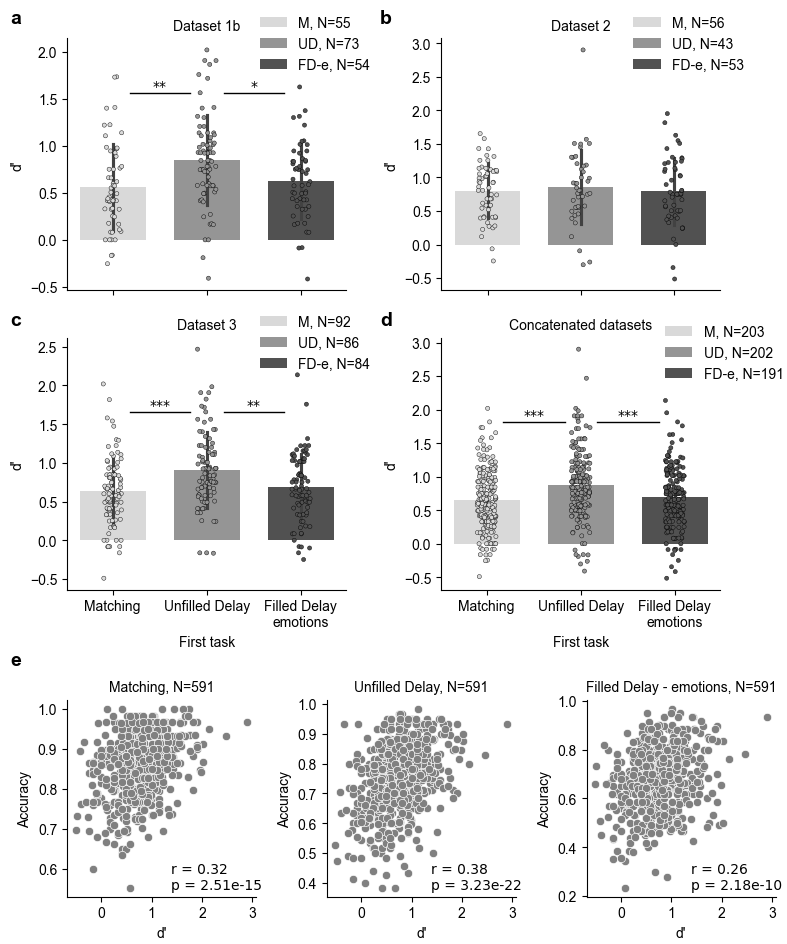

In [42]:
##
experiment2use = ['dataset_1b', 'dataset_2', 'dataset_3']
experiments_rename_dic = {'dataset_1b':'Dataset 1b', 'dataset_2':'Dataset 2', 'dataset_3': 'Dataset 3'}
palette_memory = 'Greys'

# define canvas

from cand import Canvas, Vector, Point

# reset params just in case
plt.rcdefaults()

font_size=14
legend_size=10


# CanD
a = 20
b = 16+8
# rot = 15
c = Canvas(a, b, "cm")

# set font
c.set_font("Arial", size=10)

# letters
# c.add_text("A)", Point(.02, 0.97), weight="bold", size=font_size)
# c.add_text("A)", Point(.02, 0.97), size=font_size)
c.add_text("a", Point(.02, 0.98), weight="bold", size=font_size)
c.add_text("b", Point(.49, 0.98), weight="bold", size=font_size)
c.add_text("c", Point(.02, 0.66), weight="bold", size=font_size)
c.add_text("d", Point(.49, 0.66), weight="bold", size=font_size)
c.add_text("e", Point(.02, 0.3), weight="bold", size=font_size)
           
# titles
titles = ["Accuracy per task", "d' per task", "Overal accuracy", "Overall d'"]
# c.add_text(titles[0], Point(.55, 0.97), size=font_size)
for title in titles:
    print(title)


left_offset = 1.7
top_offset = 1
middle_bottom = 9
hspace_between_plots = 2.8
bottom_offset = 1.2

hsb=1.2
vsb=1.8
vsb_top = 2.4

# ### GRID
# # top row
c.add_grid([f"d_prime_{i}" for i in range(len(experiment2use))]+["d_prime_all"], 2, Point(left_offset, middle_bottom, "cm"), Point(a-1.7, b-top_offset, "cm"), spacing=Vector(vsb_top, hsb, "cm"), unitname="grid")
c.add_grid([f"corr_{t}" for t in hue_order], 1, Point(left_offset, bottom_offset, "cm"), Point(a-.3, middle_bottom-hspace_between_plots, "cm"), spacing=Vector(vsb, hsb, "cm"))
    

### Plot d'
# to make all stripplots look the same and avoid the random jitter
# https://stackoverflow.com/questions/61944815/how-to-set-seed-for-jitter-in-seaborn-stripplot
np.random.seed(123)

# Calculate counts for each category in the x-axis (hue)
counts = df_results_dprime.groupby('first_task').size()

for i,t in enumerate(experiment2use):
    data = df_results_dprime.loc[df_results_dprime["task"]==t].copy()
    # calculate counts for each category in the x-axis (hue)
    counts = data.groupby('first_task')['userID'].nunique()#.size()
    # plot
    sns.barplot(data=data,
                y='d_prime', x='first_task', errorbar='sd', hue='first_task', legend='full', width=0.7,
                ax=c.ax(f"d_prime_{i}"), palette=palette_memory, hue_order=hue_order, order=hue_order)
    stripplot = sns.stripplot(data=data, y='d_prime', x='first_task',
                              order=hue_order, edgecolor='k', palette=palette_memory,
                              ax=c.ax(f"d_prime_{i}"), size=3, linewidth=0.3, legend=False,
                              )
    
    c.ax(f"d_prime_{i}").set_ylabel("d'")
    c.ax(f"d_prime_{i}").set_title(f"{experiments_rename_dic[t]}")
    
    # drop the x labels
    if i !=len(experiment2use)-1:
        c.ax(f"d_prime_{i}").set_xticklabels([])
        c.ax(f"d_prime_{i}").set_xlabel('')
    else:
        c.ax(f"d_prime_{i}").set_xticklabels([x.get_text().replace(' - ', '\n') for x in c.ax(f"d_prime_{i}").get_xticklabels()])
        c.ax(f"d_prime_{i}").set_xlabel('First task')
    
    sns.despine(ax=c.ax(f"d_prime_{i}"))
    

    # get the current legend labels and handles
    handles, labels = c.ax(f"d_prime_{i}").get_legend_handles_labels()

    # update the labels with counts
    new_labels = []
    for label in labels:
        # extract the original label part, split by ', N=' if it was already there
        base_label = label.split(', N=')[0]
        # append the count to the label
        new_label = f"{base_label.replace('Matching', 'M').replace('Unfilled Delay', 'UD').replace('Filled Delay - emotions', 'FD-e')}, N={counts.get(base_label, 0)}"
        new_labels.append(new_label)

    # Set the new legend with updated labels
    c.ax(f"d_prime_{i}").legend(handles, new_labels, loc='upper right', bbox_to_anchor=(1.13,1.14), frameon=False).set_zorder(10)


    
    ## add significance
    for idx, row in significance_dprime_dic[t].iterrows():
        # plot only significant
        if row['p-tukey']<0.05:
            plot_significance_pairs(hue_order.index(row['A']),#np.where(c.ax(f"d_prime_{i}").get_xticklabels() == row['A'])[0],
                                    hue_order.index(row['B']), 
                                    row['p-tukey'], c.ax(f"d_prime_{i}"), yerr=True, dh=-0.05, barh=0, x_offset=0.18)
    
           
############
# plot overal d'
sns.barplot(data=df_results_dprime,
            y='d_prime', x='first_task', errorbar='se', hue='first_task', legend='full', width=0.7,
            ax=c.ax("d_prime_all"), palette=palette_memory, hue_order=hue_order, order=hue_order)

stripplot = sns.stripplot(data=df_results_dprime, x='first_task', y='d_prime',
                          order=hue_order, edgecolor='k', palette=palette_memory,
                          ax=c.ax("d_prime_all"), size=3, linewidth=0.3, legend=False,
                          )

sns.despine(ax=c.ax("d_prime_all"))
c.ax("d_prime_all").set_ylabel("d'")
c.ax("d_prime_all").set_xlabel('First task')
c.ax("d_prime_all").set_title("Concatenated datasets")

c.ax(f"d_prime_all").set_xticklabels([x.get_text().replace(' - ', '\n') for x in c.ax(f"d_prime_{i}").get_xticklabels()])

# update legends
# for d, name in zip([data_familiarity_2, df_results_dprime], ["acc_all", "d_prime_all"]):
for d, name in zip([df_results_dprime], ["d_prime_all"]):
    # calculate counts for each category in the x-axis (hue)
    counts = d.groupby('first_task')['userID'].nunique()
    # get the current legend labels and handles
    handles, labels = c.ax(name).get_legend_handles_labels()

    # update the labels with counts
    new_labels = []
    for label in labels:
        # extract the original label part
        base_label = label.split(', N=')[0]  # Split by ', N=' if it was already there
        # append the count to the label
        new_label = f"{base_label.replace('Matching', 'M').replace('Unfilled Delay', 'UD').replace('Filled Delay - emotions', 'FD-e')}, N={counts.get(base_label, 0)}"
        new_labels.append(new_label)

    # Set the new legend with updated labels
#     c.ax(name).legend(handles, new_labels, loc='upper right', bbox_to_anchor=(1.145,1.05), frameon=False).set_zorder(10)
    c.ax(name).legend(handles, new_labels, loc='upper right', bbox_to_anchor=(1.27,1.1), frameon=False).set_zorder(10)


## add significance
for idx, row in significance_dprime_dic["d_prime_all"].iterrows():
    # plot only significant
    if row['p-tukey']<0.05:
        plot_significance_pairs(hue_order.index(row['A']),#np.where(c.ax(f"d_prime_{i}").get_xticklabels() == row['A'])[0],
                                hue_order.index(row['B']), 
                                row['p-tukey'], c.ax(f"d_prime_all"), yerr=None, dh=0.25, barh=0, x_offset=0.17)


############
# correlation

# all 4 datasets together
concat_dataset_list = experiment2use

# get scores of the concatenated all datasets
tmp = pd.concat([df_dic[f] for f in concat_dataset_list]).groupby(['userID', 'task']).correct_flt.mean().reset_index()

# add memory
df_FMP_scores = pd.concat([tmp, df_results_dprime.loc[df_results_dprime["task"].isin(concat_dataset_list)].rename(columns={"d_prime":"correct_flt"})])
# rename the 'experiment' that is called 'task' in this dataset with the correct label
for f in concat_dataset_list:
    df_FMP_scores['task'] = df_FMP_scores['task'].str.replace(f, 'd_prime')

# create a wide format 
df_FMP_scores = df_FMP_scores.pivot(index='userID', columns='task', values='correct_flt').reset_index().dropna().rename(columns={"correct_flt":"d_prime"})

for t in hue_order:
    sns.scatterplot(data=df_FMP_scores, x='d_prime', y=t, ax=c.ax(f"corr_{t}"),color='gray')

    c.ax(f"corr_{t}").set_title(f"{t}, N={df_FMP_scores.userID.unique().size}")
    c.ax(f"corr_{t}").set_xlabel("d'")
    c.ax(f"corr_{t}").set_ylabel("Accuracy")
    
    
    sns.despine(ax=c.ax(f"corr_{t}"))
    
    label_correlation(df_FMP_scores['d_prime'], df_FMP_scores[t], c.ax(f"corr_{t}"), xy=(.55, .04))


# c.debug_grid(Vector(0.5,0.5,"cm"))
c.show()
#
c.save(os.path.join(path_figures, "Fig7", 'Figure_7.png'), dpi=300)#, bbox_inches="tight")
c.save(os.path.join(path_figures, "Fig7", 'Figure_7.pdf'), dpi=300)#, bbox_inches="tight")

In [43]:
%load_ext watermark

%watermark -a 'Jan Kadlec' -nmvu -iv

Author: Jan Kadlec

Last updated: Tue Jul 01 2025

Python implementation: CPython
Python version       : 3.8.6
IPython version      : 8.12.3

Compiler    : Clang 6.0 (clang-600.0.57)
OS          : Darwin
Release     : 24.5.0
Machine     : x86_64
Processor   : i386
CPU cores   : 16
Architecture: 64bit

matplotlib: 3.7.5
arviz     : 0.15.1
numpy     : 1.24.4
pandas    : 2.0.3
IPython   : 8.12.3
pingouin  : 0.5.5
seaborn   : 0.13.2
cand      : 0.0.2
sys       : 3.8.6 (v3.8.6:db455296be, Sep 23 2020, 13:31:39) 
[Clang 6.0 (clang-600.0.57)]



[top](#top)